# DataXperience — Catálogo de Plantas y Líquenes de Colombia

## Riesgo de extinción y vacíos de protección en la flora colombiana

**Grupo 09** · Samuel Vanegas Suárez · Juan Diego Vega Pongeuta · Mariana Mancera Gómez · Jerónimo Suárez Acosta

---

| Sección | Contenido |
|---|---|
| 1 | Preparación del entorno |
| 2 | Planteamiento del problema y objetivo |
| 3 | Búsqueda y obtención de los datos |
| 4 | Comprensión del conjunto y variables |
| 5 | Limpieza y preparación |
| 6 | Análisis exploratorio (EDA) |
| 7 | Análisis estadístico |
| 8 | Patrones, relaciones e insights |
| 9 | Grafo de conocimiento en Neo4j |
| 10 | Modelo de lenguaje: selección, aplicación y evaluación |
| 11 | Conclusiones |

---
# 1. Preparación del entorno

Todo lo que usan las secciones 1 a 8 ya viene instalado en Colab. La celda siguiente solo fija
las opciones de presentación para que las tablas y las gráficas salgan legibles y con el formato
numérico en español.

In [43]:
import io, os, re, json, zipfile, textwrap, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# --- presentación de tablas ---
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

# --- identidad visual de las gráficas (la misma del informe) ---
VERDE, VERDE_CLARO, ROJO, GRIS = '#2f6f4e', '#8fbfa2', '#b5442e', '#777777'
plt.rcParams.update({
    'font.size': 10, 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'figure.facecolor': 'white',
})

def es(x, d=1):
    """Formatea un número al estilo español: 1.394,5 en vez de 1,394.5."""
    return f'{x:,.{d}f}'.replace(',', '@').replace('.', ',').replace('@', '.')

print('pandas', pd.__version__, '| numpy', np.__version__, '| matplotlib', matplotlib.__version__)

pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0


---
# 2. Planteamiento del problema y objetivo

Colombia ocupa el segundo lugar mundial en riqueza de plantas vasculares. Esa cifra responde a una
pregunta de inventario: cuántas especies hay. La pregunta de conservación es otra: de todas esas
especies, cuáles están en riesgo, dónde se concentran y cuáles carecen de cualquier figura de protección.

Responderla tropieza con una dificultad de fondo. El inventario nacional registra categoría de amenaza
para apenas 791 de los 29.917 nombres aceptados, un 2,6 %. Ese vacío puede leerse de dos maneras
opuestas: como una carencia del archivo que conviene corregir antes de analizar, o como un dato en sí
mismo que describe hasta dónde llega el conocimiento disponible. **Tomamos la segunda lectura**, y esa
decisión condiciona todo el proyecto.

> ### Pregunta principal
> ¿Cómo se distribuye el riesgo de extinción entre las plantas y líquenes de Colombia según su forma de
> vida, su condición de endemismo y su ubicación geográfica, y qué grupos se encuentran más desprotegidos?

### Preguntas de apoyo

| # | Pregunta | Variables |
|---|---|---|
| 1 | ¿Qué familias y regiones concentran la mayor proporción de endémicas? | `family`, `region_biogeografica`, `establishment_means` |
| 2 | ¿La forma de vida se asocia con la categoría de amenaza? | `life_form`, `threat_status` |
| 3 | ¿Qué proporción de endémicas carece de evaluación y dónde se concentra? | `establishment_means`, `threat_status`, `locality` |
| 4 | ¿La protección CITES coincide con las categorías de amenaza? | `appendix_cites`, `threat_status` |
| 5 | ¿Cómo varía la riqueza y la amenaza según el rango altitudinal? | `altitud_min`, `altitud_max`, `threat_status` |

### Objetivo general

Analizar la distribución del riesgo de extinción de las plantas y líquenes registrados en el Catálogo
de Plantas y Líquenes de Colombia, según su forma de vida, su condición de endemismo y su ubicación
geográfica, con el fin de identificar los grupos que se encuentran en mayor situación de desprotección.

---
# 3. Búsqueda y obtención de los datos

### Por qué esta fuente y no otra

La pregunta impuso tres condiciones: cobertura nacional completa, presencia simultánea de las variables
de los tres ejes junto con la categoría de amenaza, y una licencia que permitiera uso académico.

Se descartaron dos alternativas frecuentes:

- **Registros de ocurrencia de GBIF.** Describen dónde se ha *colectado*, no dónde *vive* la especie.
  Una zona poco visitada aparecería como pobre en especies cuando solo es pobre en muestreo.
- **Lista Roja de la UICN.** Contiene únicamente especies ya evaluadas, de modo que habría hecho
  imposible el hallazgo principal de este trabajo, que se refiere precisamente a las no evaluadas.

| Campo | Valor |
|---|---|
| Título | Catálogo de Plantas y Líquenes de Colombia |
| Editores | R. Bernal, S. R. Gradstein y M. Celis (eds.) |
| Publicador | Instituto de Ciencias Naturales, Universidad Nacional de Colombia |
| DOI | [10.15472/7avdhn](https://doi.org/10.15472/7avdhn) |
| Versión | Darwin Core Archive v1.3 · 11 de septiembre de 2023 |
| Licencia | Creative Commons Atribución (CC BY) 4.0 |
| Volumen | 47.636 nombres · 508 familias · 5.021 géneros |

### 3.1 Descarga del archivo

La función intenta tres rutas en orden: un archivo local (útil al reejecutar el cuaderno), la descarga
directa desde el IPT del SiB Colombia, y como último recurso la subida manual. Así el cuaderno corre
aunque el servidor esté caído.

In [44]:
URL_DWCA = 'https://ipt.biodiversidad.co/sib/archive.do?r=catalogo_plantas_liquenes'
RUTA_LOCAL = Path('dwca-catalogo_plantas_liquenes.zip')

def obtener_dwca():
    """Devuelve el Darwin Core Archive como objeto ZipFile."""
    if RUTA_LOCAL.exists():
        print(f'Usando el archivo local: {RUTA_LOCAL}')
        return zipfile.ZipFile(RUTA_LOCAL)

    try:
        import urllib.request
        print('Descargando desde el IPT del SiB Colombia...')
        urllib.request.urlretrieve(URL_DWCA, RUTA_LOCAL)
        print(f'Descargado: {RUTA_LOCAL.stat().st_size / 1e6:.1f} MB')
        return zipfile.ZipFile(RUTA_LOCAL)
    except Exception as e:
        print(f'La descarga falló ({e}). Sube el .zip manualmente:')
        from google.colab import files
        subido = files.upload()
        nombre = next(iter(subido))
        return zipfile.ZipFile(io.BytesIO(subido[nombre]))

dwca = obtener_dwca()
print('\nContenido del archivo:')
for n in dwca.namelist():
    print(' ', n)

Usando el archivo local: dwca-catalogo_plantas_liquenes.zip

Contenido del archivo:
  speciesprofile.txt
  taxon.txt
  description.txt
  eml.xml
  distribution.txt
  meta.xml


### 3.2 Las cuatro tablas del Darwin Core Archive

El formato empaqueta varias tablas relacionadas por un identificador común. Aquí hay cuatro, y una
de ellas no tiene una fila por especie: `description` guarda **tres** filas por nombre, una por cada
tipo de descripción. Por eso triplica el número de filas y hay que pivotarla antes de unir nada.

In [45]:
def leer_tabla(nombre):
    """Las tablas del DwC-A son texto separado por tabulación, en UTF-8."""
    return pd.read_csv(dwca.open(nombre), sep='\t', dtype=str, low_memory=False)

taxon          = leer_tabla('taxon.txt')
distribution   = leer_tabla('distribution.txt')
speciesprofile = leer_tabla('speciesprofile.txt')
description    = leer_tabla('description.txt')

resumen = pd.DataFrame({
    'tabla':   ['taxon', 'distribution', 'speciesprofile', 'description'],
    'filas':   [len(taxon), len(distribution), len(speciesprofile), len(description)],
    'columnas':[taxon.shape[1], distribution.shape[1], speciesprofile.shape[1], description.shape[1]],
    'ids únicos': [taxon.id.nunique(), distribution.id.nunique(),
                   speciesprofile.id.nunique(), description.id.nunique()],
})
display(resumen)

print('\nTipos de descripción (por eso description tiene el triple de filas):')
print(description['type'].value_counts())

,tabla,filas,columnas,ids únicos
0,taxon,47636,17,47636
1,distribution,47636,7,47636
2,speciesprofile,47636,4,47636
3,description,142908,4,47636



Tipos de descripción (por eso description tiene el triple de filas):
type
Región biogeográfica                 47636
Distribución global                  47636
Rango de distribución altitudinal    47636
Name: count, dtype: int64


### 3.3 Unión de las cuatro tablas

Se pivota `description` para convertir sus tres tipos en tres columnas, y luego se unen las cuatro
por `id` tomando `taxon` como base. La verificación no es opcional: si el resultado no conserva
exactamente 47.636 filas, la unión duplicó o perdió especies y todo lo que siga estaría mal.

In [46]:
# description: de tres filas por especie a tres columnas
descripcion_ancha = description.pivot_table(
    index='id', columns='type', values='description', aggfunc='first')

crudo = (taxon
         .merge(distribution.drop(columns=['datasetID'], errors='ignore'),   on='id', how='left')
         .merge(speciesprofile.drop(columns=['datasetID'], errors='ignore'), on='id', how='left')
         .merge(descripcion_ancha, on='id', how='left')
         .drop(columns=['datasetID'], errors='ignore'))

assert len(crudo) == len(taxon), 'La unión cambió el número de filas'
assert crudo.id.is_unique,       'La unión produjo identificadores repetidos'

print(f'Tabla unida: {crudo.shape[0]:,} filas × {crudo.shape[1]} columnas'.replace(',', '.'))
print(f'Filas esperadas: {len(taxon):,}'.replace(',', '.'), '— verificación superada')
crudo.head(3)

Tabla unida: 47.636 filas × 26 columnas
Filas esperadas: 47.636 — verificación superada


,id,taxonID,scientificNameID,acceptedNameUsageID,originalNameUsageID,scientificName,kingdom,phylum,family,genus,specificEpithet,infraspecificEpithet,taxonRank,scientificNameAuthorship,taxonomicStatus,taxonRemarks,locality,countryCode,establishmentMeans,threatStatus,appendixCITES,isHybrid,lifeForm,Distribución global,Rango de distribución altitudinal,Región biogeográfica
0,gbif.org/species/5325293,gbif.org/species/5325293,gbif.org/species/5325293,NaN,19145,Aa argyrolepis,Plantae,Magnoliopsida,Orchidaceae,Aa,argyrolepis,NaN,Especie,Rchb.f.,Aceptado,NaN,Desconocido,CO,Nativa,NaN,II,FALSE,Hierba,Colombia a Perú y N Brasil,NaN,Andes
1,gbif.org/species/5325285,gbif.org/species/5325285,gbif.org/species/5325285,NaN,19146,Aa colombiana,Plantae,Magnoliopsida,Orchidaceae,Aa,colombiana,NaN,Especie,Schltr.,Aceptado,Tipo de Colombia | EspecimenRepresentativo: Ma...,"Caldas, Cesar, Cundinamarca, Nariño, Risaralda",CO,Nativa,NaN,II,FALSE,Hierba,Colombia a Bolivia; Honduras,2600 - 4300 msnm,"Andes, Sierra Nevada de Santa Marta"
2,gbif.org/species/5325270,gbif.org/species/5325270,gbif.org/species/5325270,NaN,19147,Aa denticulata,Plantae,Magnoliopsida,Orchidaceae,Aa,denticulata,NaN,Especie,Schltr.,Aceptado,Tipo de Colombia | EspecimenRepresentativo: Ma...,Cauca,CO,Nativa,NaN,II,FALSE,Hierba,Honduras a Ecuador,3500 - 3500 msnm,Andes


---
# 4. Comprensión del conjunto y descripción de las variables

El catálogo es un **inventario de nombres**, no un registro de observaciones. Cada fila es un nombre
científico y las columnas lo describen. No contiene coordenadas, fechas de colecta ni conteos de
individuos: en el estándar Darwin Core esto se llama *lista de chequeo taxonómica*.

La consecuencia metodológica es importante y conviene fijarla ahora: como no es un muestreo, el
esfuerzo de colecta **no** distorsiona los conteos por región.

In [47]:
def auditar(df):
    """Calidad columna a columna: tipo, vacíos y cardinalidad."""
    return pd.DataFrame({
        'tipo':      df.dtypes.astype(str),
        'no nulos':  df.notna().sum(),
        'nulos':     df.isna().sum(),
        '% nulos':   (100 * df.isna().mean()).round(1),
        'distintos': df.nunique(),
        'ejemplo':   [df[c].dropna().iloc[0] if df[c].notna().any() else '—' for c in df.columns],
    })

auditoria = auditar(crudo)
display(auditoria)

completitud = 100 * (1 - crudo.isna().sum().sum() / crudo.size)
print(f'Celdas vacías: {crudo.isna().sum().sum():,}'.replace(',', '.'),
      f'| Completitud: {completitud:.1f} sobre 100')

,tipo,no nulos,nulos,% nulos,distintos,ejemplo
id,object,47636,0,0.00,47636,gbif.org/species/5325293
taxonID,object,47636,0,0.00,47636,gbif.org/species/5325293
scientificNameID,object,47636,0,0.00,47636,gbif.org/species/5325293
acceptedNameUsageID,object,17719,29917,62.80,9677,19150
originalNameUsageID,object,47636,0,0.00,47636,19145
scientificName,object,47636,0,0.00,47636,Aa argyrolepis
kingdom,object,47636,0,0.00,2,Plantae
phylum,object,47635,1,0.00,10,Magnoliopsida
family,object,47636,0,0.00,508,Orchidaceae
genus,object,47636,0,0.00,5021,Aa


Celdas vacías: 317.039 | Completitud: 74.4 sobre 100


### 4.1 La variable de control que no estaba en la pregunta

`taxonomicStatus` distingue los nombres vigentes de los sinónimos. Un sinónimo es un nombre antiguo de
una especie que hoy se llama de otro modo, **no una especie distinta**. Los 17.719 sinónimos del
catálogo, un 37,2 % del total, inflan cualquier conteo que no los filtre.

El universo real de análisis no son los 47.636 nombres sino los 29.917 aceptados.

In [48]:
print(crudo.taxonomicStatus.value_counts(), '\n')
print(crudo.kingdom.value_counts(), '\n')
print('Familias:', crudo.family.nunique(), '| Géneros:', crudo.genus.nunique())

print('\nCategoría de amenaza (nulo = nunca evaluada):')
print(crudo.threatStatus.value_counts(dropna=False).head())
print('\nApéndice CITES (nulo = sin apéndice):')
print(crudo.appendixCITES.value_counts(dropna=False).head())

taxonomicStatus
Aceptado    29917
Sinónimo    17719
Name: count, dtype: int64 

kingdom
Plantae    44754
Fungi       2882
Name: count, dtype: int64 

Familias: 508 | Géneros: 5021

Categoría de amenaza (nulo = nunca evaluada):
threatStatus
NaN    46845
VU       414
EN       258
CR       119
Name: count, dtype: int64

Apéndice CITES (nulo = sin apéndice):
appendixCITES
NaN    45264
II      2362
I          7
III        3
Name: count, dtype: int64


### 4.2 Los tres problemas de forma que impiden analizar

El archivo es estructuralmente sano —cero filas duplicadas, identificadores íntegros, nombres sin
repetir— pero ninguna de las variables clave se puede usar directamente:

1. **Campos multivalor.** Una celda de `locality` puede decir `Caldas, Cesar, Nariño`. Mientras no se
   separen, esa combinación cuenta como una categoría propia.
2. **Números guardados como texto.** El rango altitudinal viene escrito `2600 - 4300 msnm`.
3. **Faltantes enmascarados.** `Desconocido` figura como si fuera un departamento más.

In [49]:
print('Filas duplicadas:', crudo.duplicated().sum())
print('Nombres científicos repetidos:', crudo.scientificName.duplicated().sum())
print()
print('Combinaciones distintas en locality :', crudo.locality.nunique())
print('Combinaciones distintas en lifeForm :', crudo.lifeForm.nunique())
print()
print('Rango altitudinal, tal como viene:')
print(crudo['Rango de distribución altitudinal'].dropna().head(3).to_list())
print()
desconocido = crudo.locality.astype(str).str.contains('Desconocido').sum()
hibrio      = (crudo.taxonRank == 'Híbrio').sum()
print(f'Registros con localidad "Desconocido" : {desconocido}')
print(f'Registros con "Híbrio" (error de digitación por "Híbrido"): {hibrio}')

Filas duplicadas: 0
Nombres científicos repetidos: 0

Combinaciones distintas en locality : 8629
Combinaciones distintas en lifeForm : 239

Rango altitudinal, tal como viene:
['2600 - 4300 msnm', '3500 - 3500 msnm', '3200 - 3720 msnm']

Registros con localidad "Desconocido" : 1019
Registros con "Híbrio" (error de digitación por "Híbrido"): 62


---
# 5. Limpieza y preparación de los datos

Esta es la sección de la que dependen tres de los cuatro hallazgos del proyecto. La sección 8.7
muestra qué habría pasado sin ella.

### El criterio: no todo vacío es un error

La decisión más delicada fue qué hacer con las celdas vacías, porque no todas significan lo mismo:

| Situación | Tratamiento | Por qué |
|---|---|---|
| `threatStatus` vacío | Etiquetar `'No evaluada'` | El vacío **informa**: nadie revisó esa especie. Es el hallazgo principal del proyecto |
| `appendixCITES` vacío | Etiquetar `'No listada'` | Igual: la ausencia de apéndice es un dato, no un error |
| `lifeForm`, `locality`, origen vacíos | Marcar `'Sin registrar'` | El dato simplemente se desconoce; queda visible y filtrable |
| Altitud vacía | Dejar vacío | Estimarla sería inventarla |
| `locality = 'Desconocido'` | Convertir a faltante | Contado como lugar, aparenta una cobertura que el catálogo no tiene |

**Ninguna fila se elimina.** El filtrado por nombres aceptados se hace en el momento del análisis, no
en la limpieza, de modo que los sinónimos siguen disponibles para trazar el enlace entre un nombre
antiguo y su nombre vigente.

In [50]:
# --- configuración de la limpieza, en un solo lugar ---

RENOMBRES = {
    'Distribución global':               'distribucion_global',
    'Región biogeográfica':              'region_biogeografica',
    'Rango de distribución altitudinal': 'rango_altitudinal',
    'acceptedNameUsageID':               'accepted_name_usage_id',
    'originalNameUsageID':               'original_name_usage_id',
    'appendixCITES':                     'appendix_cites',
}

# columnas que no aportan información al análisis
DESCARTAR = ['taxonID', 'scientificNameID', 'countryCode',
             'Rango de distribución altitudinal']

# vacíos que informan: se etiquetan, no se imputan
ETIQUETAS = {'threatStatus': 'No evaluada', 'appendixCITES': 'No listada'}

# vacíos que solo indican desconocimiento
SIN_REGISTRAR = ['establishmentMeans', 'lifeForm', 'locality',
                 'Región biogeográfica', 'Distribución global',
                 'scientificNameAuthorship']

def a_snake(nombre):
    """camelCase -> snake_case, respetando los renombres explícitos."""
    if nombre in RENOMBRES:
        return RENOMBRES[nombre]
    return re.sub(r'(?<!^)(?=[A-Z])', '_', nombre).lower()

def extraer_altitud(texto):
    """'2600 - 4300 msnm' -> (2600.0, 4300.0). Devuelve NaN si no hay dos números."""
    if pd.isna(texto):
        return (np.nan, np.nan)
    numeros = re.findall(r'-?\d+', str(texto))
    if len(numeros) < 2:
        return (np.nan, np.nan)
    return (float(numeros[0]), float(numeros[1]))

### 5.1 La función de limpieza

Son 19 intervenciones agrupadas en ocho pasos. El orden importa: `Desconocido` se convierte en
faltante **antes** de marcar los faltantes como `'Sin registrar'`, para que acabe en la misma
categoría que el resto de los desconocidos.

In [51]:
def limpiar(df):
    df = df.copy()

    # 1. etiquetar los vacíos que informan
    for col, etiqueta in ETIQUETAS.items():
        df[col] = df[col].fillna(etiqueta)

    # 2. 'Desconocido' no es un departamento: es un dato ausente
    df['locality'] = df['locality'].replace('Desconocido', np.nan)

    # 3. el resto de los vacíos quedan visibles y filtrables
    for col in SIN_REGISTRAR:
        df[col] = df[col].fillna('Sin registrar')

    # 4. corregir el error de digitación que parte la categoría en dos
    df['taxonRank'] = df['taxonRank'].replace('Híbrio', 'Híbrido')

    # 5. altitud: de texto a dos columnas numéricas
    pares = df['Rango de distribución altitudinal'].apply(extraer_altitud)
    df['altitud_min'] = [p[0] for p in pares]
    df['altitud_max'] = [p[1] for p in pares]

    # una altitud negativa es imposible en este catálogo: se anula el par completo
    imposible = (df['altitud_min'] < 0) | (df['altitud_max'] < 0)
    df.loc[imposible, ['altitud_min', 'altitud_max']] = np.nan

    # 6. descartar columnas sin información y normalizar los nombres
    df = df.drop(columns=DESCARTAR)
    df = df.rename(columns={c: a_snake(c) for c in df.columns})

    # 7. variables derivadas que la pregunta necesitaba y el archivo no traía
    df['amplitud_altitudinal'] = df['altitud_max'] - df['altitud_min']
    df['altitud_media']        = (df['altitud_max'] + df['altitud_min']) / 2
    df['n_regiones']    = df['region_biogeografica'].apply(
        lambda v: np.nan if v == 'Sin registrar' else len(str(v).split(',')))
    df['n_formas_vida'] = df['life_form'].apply(
        lambda v: np.nan if v == 'Sin registrar' else len(str(v).split(',')))

    # 8. banderas booleanas: simplifican todos los filtros posteriores
    df['es_endemica']  = df['establishment_means'].str.contains('Endémica', na=False)
    df['es_amenazada'] = df['threat_status'].isin(['CR', 'EN', 'VU'])
    df['es_aceptado']  = df['taxonomic_status'].eq('Aceptado')

    # normalizaciones para comparar en escala común
    m = df['altitud_media']
    df['altitud_media_minmax'] = (m - m.min()) / (m.max() - m.min())
    df['altitud_media_zscore'] = (m - m.mean()) / m.std()

    df['locality'] = df['locality'].fillna('Sin registrar')
    return df

limpio = limpiar(crudo)
print(f'{crudo.shape[0]:,} × {crudo.shape[1]}'.replace(',', '.'), '->',
      f'{limpio.shape[0]:,} × {limpio.shape[1]}'.replace(',', '.'))

47.636 × 26 -> 47.636 × 33


### 5.2 Antes y después

La limpieza no elimina filas; sube la completitud etiquetando lo que estaba vacío y añade siete
variables derivadas que el archivo original no traía.

,Antes,Después
Dimensiones,47.636 × 26,47.636 × 33
Celdas vacías,317.039,266.046
Completitud sobre 100,74.4,83.1
Filas descartadas,—,Ninguna
Columnas derivadas,—,+7


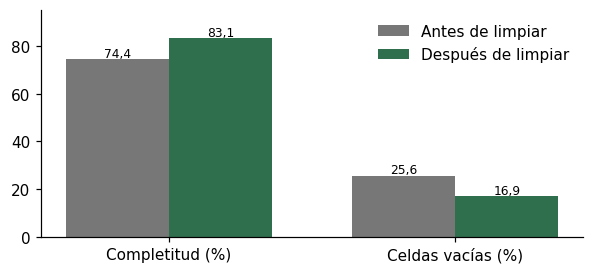

In [52]:
def completitud(df):
    return 100 * (1 - df.isna().sum().sum() / df.size)

comparacion = pd.DataFrame({
    'Antes':   [f'{crudo.shape[0]:,} × {crudo.shape[1]}'.replace(',', '.'),
                f'{crudo.isna().sum().sum():,}'.replace(',', '.'),
                f'{completitud(crudo):.1f}', '—', '—'],
    'Después': [f'{limpio.shape[0]:,} × {limpio.shape[1]}'.replace(',', '.'),
                f'{limpio.isna().sum().sum():,}'.replace(',', '.'),
                f'{completitud(limpio):.1f}', 'Ninguna', '+7'],
}, index=['Dimensiones', 'Celdas vacías', 'Completitud sobre 100',
          'Filas descartadas', 'Columnas derivadas'])
display(comparacion)

fig, ax = plt.subplots(figsize=(5.5, 2.6))
x, w = np.arange(2), 0.36
antes   = [completitud(crudo),  100 - completitud(crudo)]
despues = [completitud(limpio), 100 - completitud(limpio)]
ax.bar(x - w/2, antes,   w, color=GRIS,  label='Antes de limpiar')
ax.bar(x + w/2, despues, w, color=VERDE, label='Después de limpiar')
for i, (a, b) in enumerate(zip(antes, despues)):
    ax.text(i - w/2, a + 1, es(a), ha='center', fontsize=8)
    ax.text(i + w/2, b + 1, es(b), ha='center', fontsize=8)
ax.set_xticks(x, ['Completitud (%)', 'Celdas vacías (%)'])
ax.set_ylim(0, 95); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### 5.3 El universo de análisis

A partir de aquí casi todo se calcula sobre `aceptados`: los 29.917 nombres vigentes. Mezclar
sinónimos es el error que invierte el ranking de familias en la sección 8.7.

También se define un ayudante para los campos multivalor. Es la pieza que hace posible los hallazgos
8.1 y 8.2: sin él, `Hierba, Epífita` cuenta como una tercera forma de vida que no existe.

In [53]:
aceptados = limpio[limpio.es_aceptado].copy()
print(f'Universo de análisis: {len(aceptados):,} nombres aceptados'.replace(',', '.'),
      f'({len(limpio) - len(aceptados):,} sinónimos apartados)'.replace(',', '.'))

RELLENOS = {'Sin registrar', 'No evaluada', 'No listada', 'Desconocido', 'nan', ''}

def separar(df, columna, sep=','):
    """Una fila por cada valor de un campo multivalor, sin las etiquetas de relleno."""
    largo = df.copy()
    largo[columna] = largo[columna].astype(str).str.split(sep)
    largo = largo.explode(columna)
    largo[columna] = largo[columna].str.strip()
    return largo[~largo[columna].isin(RELLENOS)]

print('\nFormas de vida antes de separar:', aceptados.life_form.nunique())
print('Formas de vida después de separar:',
      separar(aceptados, 'life_form').life_form.nunique())

Universo de análisis: 29.917 nombres aceptados (17.719 sinónimos apartados)

Formas de vida antes de separar: 240
Formas de vida después de separar: 22


---
# 6. Análisis exploratorio de datos

### 6.1 Distribución de las variables numéricas

In [54]:
numericas = ['altitud_min', 'altitud_max', 'altitud_media',
             'amplitud_altitudinal', 'n_regiones', 'n_formas_vida']

descriptivos = limpio[numericas].describe().T[['count', 'mean', '50%', 'std', 'min', 'max']]
descriptivos.columns = ['n', 'media', 'mediana', 'desv. típica', 'mín', 'máx']
display(descriptivos.round(2))

print('Asimetría de altitud_media:', round(limpio.altitud_media.skew(), 2))

,n,media,mediana,desv. típica,mín,máx
altitud_min,"26,574.00","1,001.40",500.00,"1,063.78",0.00,"4,900.00"
altitud_max,"26,574.00","1,786.99","1,800.00","1,238.48",0.00,"5,000.00"
altitud_media,"26,574.00","1,394.19","1,200.00","1,081.32",0.00,"4,950.00"
amplitud_altitudinal,"26,574.00",785.59,500.00,808.62,0.00,"4,650.00"
n_regiones,"27,067.00",1.74,1.00,1.37,1.00,10.00
n_formas_vida,"24,241.00",1.51,1.00,0.71,1.00,7.00


Asimetría de altitud_media: 0.52


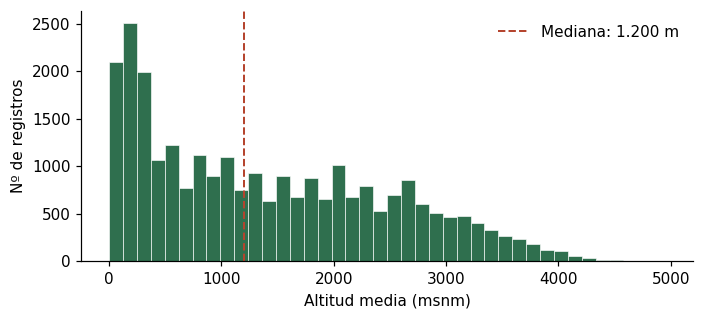

Media 1.394 m · Mediana 1.200 m


In [55]:
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(limpio.altitud_media.dropna(), bins=40, color=VERDE, edgecolor='white', linewidth=0.4)
mediana = limpio.altitud_media.median()
ax.axvline(mediana, color=ROJO, ls='--', lw=1.3, label=f'Mediana: {es(mediana, 0)} m')
ax.set_xlabel('Altitud media (msnm)'); ax.set_ylabel('Nº de registros')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

print(f'Media {es(limpio.altitud_media.mean(), 0)} m · Mediana {es(mediana, 0)} m')

La distribución es asimétrica a la derecha: la media queda por encima de la mediana, de modo que **no
existe una altura promedio representativa del catálogo**. Describirlo con un solo número induce a
error y obliga a trabajar por franjas, que es lo que hace la sección 8.5.

### 6.2 Valores atípicos: detectar no es eliminar

El criterio de 1,5 veces el rango intercuartílico señala casos con amplitudes altitudinales muy
grandes. **Se inspeccionaron y se conservaron**: son especies generalistas reales, no errores de
registro, y eliminarlas habría sesgado el análisis altitudinal hacia las especies de rango estrecho.

Atípicos por IQR: 199 de 26.574 (0.7 %)


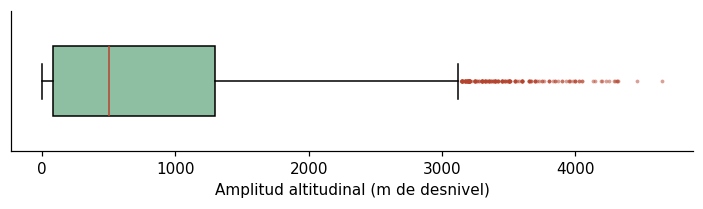


Los cinco casos más extremos, para inspección manual:


,scientific_name,family,altitud_min,altitud_max,amplitud_altitudinal
43056,Stevia lucida,Asteraceae,250.00,"4,900.00","4,650.00"
17171,Galinsoga quadriradiata,Asteraceae,40.00,"4,500.00","4,460.00"
9229,Cladonia subradiata,Cladoniaceae,230.00,"4,550.00","4,320.00"
6851,Campylopus richardii,Dicranaceae,120.00,"4,435.00","4,315.00"
12717,Dictyonema glabratum,Atheliaceae,240.00,"4,550.00","4,310.00"


In [56]:
def atipicos_iqr(serie, k=1.5):
    """Máscara booleana de valores fuera de [Q1 - k·IQR, Q3 + k·IQR]."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - k * iqr) | (serie > q3 + k * iqr)

amplitud = limpio.amplitud_altitudinal.dropna()
marcados = atipicos_iqr(amplitud)
print(f'Atípicos por IQR: {marcados.sum()} de {len(amplitud):,}'.replace(',', '.'),
      f'({100 * marcados.mean():.1f} %)')

fig, ax = plt.subplots(figsize=(6.5, 2))
bp = ax.boxplot(amplitud, vert=False, widths=0.5, patch_artist=True,
                flierprops=dict(marker='o', markersize=2.5, markerfacecolor=ROJO,
                                markeredgecolor='none', alpha=0.5))
bp['boxes'][0].set_facecolor(VERDE_CLARO); bp['medians'][0].set_color(ROJO)
ax.set_yticks([]); ax.set_xlabel('Amplitud altitudinal (m de desnivel)')
plt.tight_layout(); plt.show()

print('\nLos cinco casos más extremos, para inspección manual:')
display(limpio.nlargest(5, 'amplitud_altitudinal')
        [['scientific_name', 'family', 'altitud_min', 'altitud_max', 'amplitud_altitudinal']])

### 6.3 Relación entre variables numéricas

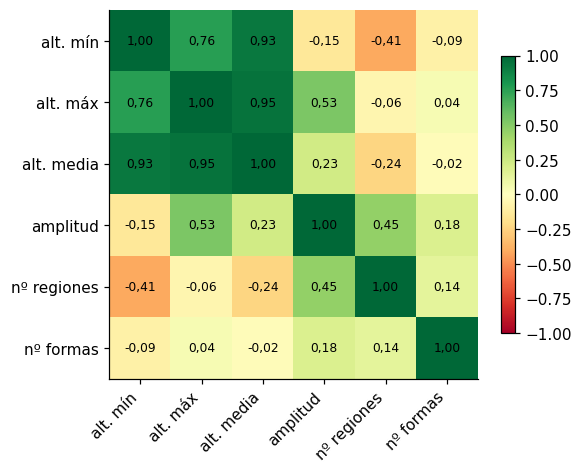

In [57]:
corr = limpio[numericas].corr()
etiquetas = ['alt. mín', 'alt. máx', 'alt. media', 'amplitud', 'nº regiones', 'nº formas']

fig, ax = plt.subplots(figsize=(5.4, 4.4))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(etiquetas)), etiquetas, rotation=45, ha='right')
ax.set_yticks(range(len(etiquetas)), etiquetas)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}'.replace('.', ','),
                ha='center', va='center', fontsize=8)
fig.colorbar(im, shrink=0.75); plt.tight_layout(); plt.show()

Tres lecturas relevantes para lo que viene:

- **Altitud mínima y máxima, 0,76.** Describen el mismo rango; usarlas juntas introduciría
  información redundante. Por eso los cruces posteriores usan solo `altitud_media`.
- **Amplitud y altitud mínima, −0,15.** Empezar más arriba no implica abarcar más desnivel: la
  montaña no ofrece más margen vertical que las tierras bajas. Esto anticipa el resultado de 8.5.
- **Número de regiones y amplitud, 0,45.** Ocupar más territorio obliga a tolerar más variación de altura.

---
# 7. Análisis estadístico

### Alcance de los contrastes

El catálogo es una **enumeración completa** de la población conocida, no una muestra aleatoria. Las
proporciones calculadas son parámetros de esa población, no estimaciones sujetas a error de muestreo.
Los contrastes se usan aquí para **dimensionar diferencias**, no para inferir sobre una población mayor.

> ### Advertencia que recorre todo el análisis
> Las proporciones de amenaza se calculan sobre especies evaluadas y no evaluadas conjuntamente. Como
> el 98,3 % del catálogo nunca ha sido evaluado, **toda tasa de amenaza de este cuaderno es un límite
> inferior**: mide amenaza reconocida, no amenaza real. Los grupos mejor estudiados aparecerán
> sistemáticamente como más amenazados, y eso es una propiedad del estado del conocimiento antes que
> de la flora.

### 7.1 Asociación entre forma de vida y amenaza

Tabla de contingencia restringida a las formas con al menos 100 especies aceptadas, comparada contra
la proporción de base del conjunto.

In [58]:
base = 100 * aceptados.es_amenazada.mean()
print(f'Proporción de base del conjunto: {es(base, 2)} %')

formas = separar(aceptados, 'life_form')
tabla_formas = (formas.groupby('life_form')
                .agg(especies=('es_amenazada', 'size'), amenazadas=('es_amenazada', 'sum')))
tabla_formas = tabla_formas[tabla_formas.especies >= 100]
tabla_formas['% amenaza'] = (100 * tabla_formas.amenazadas / tabla_formas.especies).round(2)
tabla_formas['razón vs. base'] = (tabla_formas['% amenaza'] / base).round(1)
display(tabla_formas.sort_values('% amenaza', ascending=False))

Proporción de base del conjunto: 2,64 %


,especies,amenazadas,% amenaza,razón vs. base
life_form,,,,
Palma solitaria,138,31,22.46,8.50
Epífita,4311,247,5.73,2.20
Hierba,12399,427,3.44,1.30
Árbol,5339,156,2.92,1.10
Subarbusto,1520,28,1.84,0.70
Arbusto,5847,90,1.54,0.60
Trepadora,2382,23,0.97,0.40
Arbolito,2460,11,0.45,0.20
Liana,1181,5,0.42,0.20


La asociación existe y es fuerte: entre la forma más expuesta y la menos expuesta median más de
cuarenta veces de diferencia.

El valor de las palmas solitarias debe leerse con la cautela que impone su tamaño: son 138 especies,
de modo que cada especie amenazada desplaza el porcentaje en 0,7 puntos. Aun así, 31 amenazadas sobre
138 no es un resultado que la variabilidad de un grupo pequeño explique por sí sola.

### 7.2 Comparación de proporciones entre subgrupos

¿Una especie endémica tiene más probabilidad de estar amenazada que una que no lo es?

In [59]:
endemicas    = aceptados[aceptados.es_endemica]
no_endemicas = aceptados[~aceptados.es_endemica]

p_end = 100 * endemicas.es_amenazada.mean()
p_no  = 100 * no_endemicas.es_amenazada.mean()
print(f'Endémicas    : {es(p_end, 1)} % amenazadas  (n = {len(endemicas):,})'.replace(',', '.'))
print(f'No endémicas : {es(p_no, 1)} % amenazadas  (n = {len(no_endemicas):,})'.replace(',', '.'))
print(f'Razón        : {p_end / p_no:.1f} veces más')

# el mecanismo biológico que lo explica
una_region = (endemicas.n_regiones == 1).sum()
print(f'\nEndémicas presentes en una sola región: {una_region:,}'.replace(',', '.'),
      f'({100 * una_region / endemicas.n_regiones.notna().sum():.0f} % de las que tienen región registrada)')
print('Sin poblaciones de respaldo en otro territorio: ese es el mecanismo.')

Endémicas    : 7.6 % amenazadas  (n = 6.401)
No endémicas : 1.3 % amenazadas  (n = 23.516)
Razón        : 5.9 veces más

Endémicas presentes en una sola región: 5.487 (88 % de las que tienen región registrada)
Sin poblaciones de respaldo en otro territorio: ese es el mecanismo.


---
# 8. Hallazgo de patrones, relaciones e insights

Las nueve consultas del análisis se escribieron a mano en Cypher y se ejecutaron sobre el grafo
(sección 9). Aquí se reproducen con pandas sobre el mismo conjunto limpio, y la sección 9.4 verifica
que los dos caminos dan el mismo número. **Ningún modelo de lenguaje interviene en esta sección.**

### 8.1 Las palmas, no los árboles

La hipótesis intuitiva sitúa a los árboles como el grupo más amenazado, por ser los que pierde la
deforestación. Los datos apuntan a otro lado.

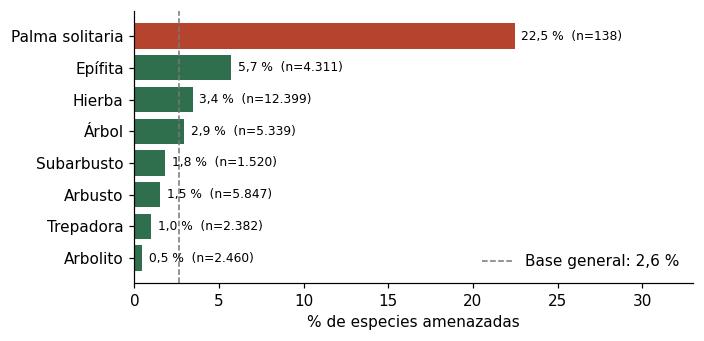

Familias a las que pertenecen las palmas solitarias: ['Arecaceae']
Con algún apéndice CITES: 0 de 138


In [60]:
orden = tabla_formas.sort_values('% amenaza').tail(8)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
colores = [ROJO if p > 10 else VERDE for p in orden['% amenaza']]
ax.barh(orden.index, orden['% amenaza'], color=colores)
ax.axvline(base, color=GRIS, ls='--', lw=1, label=f'Base general: {es(base, 1)} %')
for i, (p, n) in enumerate(zip(orden['% amenaza'], orden.especies)):
    ax.text(p + 0.4, i, f'{es(p, 1)} %  (n={es(n, 0)})', va='center', fontsize=8)
ax.set_xlabel('% de especies amenazadas'); ax.set_xlim(0, 33)
ax.legend(frameon=False); plt.tight_layout(); plt.show()

# el detalle que convierte el dato en un hallazgo de conservación
palmas = separar(aceptados, 'life_form')
palmas = palmas[palmas.life_form == 'Palma solitaria']
print('Familias a las que pertenecen las palmas solitarias:', palmas.family.unique())
print('Con algún apéndice CITES:', (palmas.appendix_cites != 'No listada').sum(), 'de', len(palmas))

**El grupo con mayor proporción de especies amenazadas del catálogo carece por completo de protección
comercial internacional.** Las 138 palmas solitarias pertenecen todas a la familia *Arecaceae* y
ninguna figura en un apéndice CITES.

### 8.2 El endemismo no coincide con la riqueza

Una región con muchas especies no es necesariamente una región con muchas especies exclusivas.

,especies,endemicas,% endemismo
region_biogeografica,,,
Andes,18327,4822,26.30
Pacífico,6063,862,14.20
Amazonia,5819,207,3.60
Valle del Magdalena,3442,396,11.50
Guayana y Serranía de La Macarena,3201,187,5.80
Llanura del Caribe,2910,120,4.10
Orinoquia,2842,99,3.50
Sierra Nevada de Santa Marta,2552,332,13.00
Valle del Cauca,1423,82,5.80


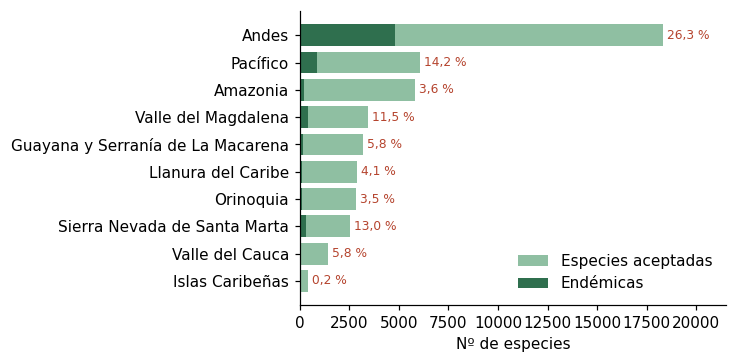

In [61]:
regiones = separar(aceptados, 'region_biogeografica')
por_region = (regiones.groupby('region_biogeografica')
              .agg(especies=('es_endemica', 'size'), endemicas=('es_endemica', 'sum')))
por_region['% endemismo'] = (100 * por_region.endemicas / por_region.especies).round(1)
display(por_region.sort_values('especies', ascending=False))

g = por_region.sort_values('especies')
fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.barh(g.index, g.especies,  color=VERDE_CLARO, label='Especies aceptadas')
ax.barh(g.index, g.endemicas, color=VERDE,       label='Endémicas')
for i, (t, p) in enumerate(zip(g.especies, g['% endemismo'])):
    ax.text(t + 200, i, f'{es(p, 1)} %', va='center', fontsize=8, color=ROJO)
ax.set_xlabel('Nº de especies'); ax.set_xlim(0, 21500)
ax.legend(frameon=False, loc='lower right'); plt.tight_layout(); plt.show()

In [62]:
# lo mismo por familia: el podio cambia respecto al de tamaño
por_familia = (aceptados.groupby('family')
               .agg(especies=('es_endemica', 'size'), endemicas=('es_endemica', 'sum')))
por_familia = por_familia[por_familia.especies >= 50]
por_familia['% endemismo'] = (100 * por_familia.endemicas / por_familia.especies).round(1)

print('Familias con mayor proporción de endémicas (mín. 50 especies):')
display(por_familia.nlargest(8, '% endemismo'))
print('Familias más numerosas:')
display(por_familia.nlargest(5, 'especies'))

Familias con mayor proporción de endémicas (mín. 50 especies):


,especies,endemicas,% endemismo
family,,,
Campanulaceae,254,150,59.10
Acanthaceae,392,214,54.60
Ericaceae,301,160,53.20
Araliaceae,175,82,46.90
Primulaceae,184,77,41.80
Orchidaceae,3656,1483,40.60
Heliconiaceae,100,40,40.00
Lobariaceae,104,39,37.50


Familias más numerosas:


,especies,endemicas,% endemismo
family,,,
Orchidaceae,3656,1483,40.60
Fabaceae,1444,155,10.70
Asteraceae,1434,527,36.80
Rubiaceae,1168,239,20.50
Melastomataceae,1053,311,29.50


La conclusión operativa: **priorizar por número de especies y priorizar por exclusividad conducen a
listas distintas.** Las orquídeas son la familia más numerosa y aun así no encabezan el endemismo.

### 8.3 El vacío de evaluación

Es el hallazgo de mayor peso del proyecto.

Especies endémicas aceptadas : 6.401
Nunca evaluadas              : 5.912 (92,4 %)


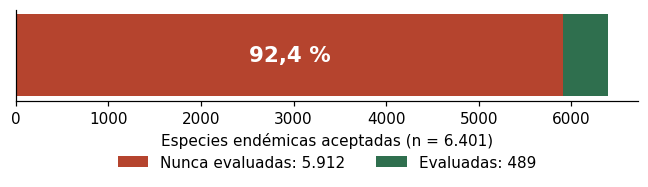


Departamentos donde se concentran las endémicas sin evaluar:
locality
Antioquia       1603
Valle           1188
Cundinamarca    1068
Cauca            819
Chocó            819
Name: count, dtype: int64


In [63]:
sin_evaluar = endemicas[endemicas.threat_status == 'No evaluada']
pct = 100 * len(sin_evaluar) / len(endemicas)

print(f'Especies endémicas aceptadas : {len(endemicas):,}'.replace(',', '.'))
print(f'Nunca evaluadas              : {len(sin_evaluar):,}'.replace(',', '.'), f'({es(pct, 1)} %)')

fig, ax = plt.subplots(figsize=(6, 2.2))
evaluadas = len(endemicas) - len(sin_evaluar)
ax.barh([0], [len(sin_evaluar)], color=ROJO,  label=f'Nunca evaluadas: {es(len(sin_evaluar), 0)}')
ax.barh([0], [evaluadas], left=[len(sin_evaluar)], color=VERDE, label=f'Evaluadas: {es(evaluadas, 0)}')
ax.text(len(sin_evaluar) / 2, 0, f'{es(pct, 1)} %', ha='center', va='center',
        color='white', fontsize=14, fontweight='bold')
ax.set_yticks([]); ax.set_xlabel(f'Especies endémicas aceptadas (n = {es(len(endemicas), 0)})')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.45), ncol=2)
plt.tight_layout(); plt.show()

print('\nDepartamentos donde se concentran las endémicas sin evaluar:')
print(separar(sin_evaluar, 'locality').locality.value_counts().head(5))

Que una especie no esté evaluada significa que **nadie ha revisado su situación**. Sin evaluación no
entra en los planes de conservación, no puede alegarse su riesgo ante un proyecto que afecte su
hábitat y no aparece en ninguna lista de prioridades.

El vacío no es una deficiencia del archivo que convenga imputar o descartar: **es la respuesta a la pregunta.**

### 8.4 CITES y la evaluación nacional no coinciden

La desalineación entre riesgo declarado y protección concedida ocurre en ambos sentidos, y en ambos
es mayoritaria.

In [64]:
criticas   = aceptados[aceptados.threat_status == 'CR']
con_cites  = aceptados[aceptados.appendix_cites != 'No listada']

cr_sin_cites   = (criticas.appendix_cites == 'No listada').sum()
cites_sin_eval = (con_cites.threat_status == 'No evaluada').sum()
cites_orquideas= (con_cites.family == 'Orchidaceae').sum()

contrastes = pd.DataFrame({
    'casos': [f'{cr_sin_cites} de {len(criticas)}',
              f'{cites_sin_eval:,} de {len(con_cites):,}'.replace(',', '.'),
              f'{cites_orquideas:,} de {len(con_cites):,}'.replace(',', '.')],
    'proporción': [f'{100 * cr_sin_cites / len(criticas):.1f} %',
                   f'{100 * cites_sin_eval / len(con_cites):.1f} %',
                   f'{100 * cites_orquideas / len(con_cites):.1f} %'],
}, index=['En peligro crítico sin ningún apéndice CITES',
          'Con apéndice CITES que nunca fueron evaluadas',
          'Apéndices CITES que corresponden a orquídeas'])
display(contrastes)

,casos,proporción
En peligro crítico sin ningún apéndice CITES,104 de 119,87.4 %
Con apéndice CITES que nunca fueron evaluadas,2.165 de 2.372,91.3 %
Apéndices CITES que corresponden a orquídeas,2.241 de 2.372,94.5 %


La explicación está en la naturaleza de cada instrumento. **CITES regula comercio internacional y
sigue la demanda comercial, no el riesgo de extinción.** De ahí que la enorme mayoría de los
apéndices correspondan a orquídeas, el grupo con mayor tráfico. Tratar la presencia en un apéndice
como indicador de protección frente al riesgo es un error de interpretación.

### 8.5 Entre más alto, más riesgo

,especies,amenazadas,endemicas,% amenaza,% endemismo
franja,,,,,
0-500,7667,166,1039,2.17,13.60
500-1000,4017,73,592,1.82,14.70
1000-1500,3420,71,682,2.08,19.90
1500-2000,3113,106,990,3.41,31.80
2000-2500,3034,133,1081,4.38,35.60
2500-3000,2668,95,832,3.56,31.20
3000-3500,1650,84,559,5.09,33.90
>3500,976,30,294,3.07,30.10


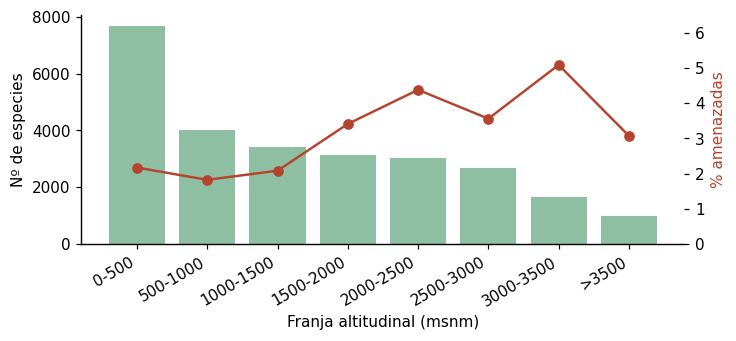

In [65]:
franjas = ['0-500', '500-1000', '1000-1500', '1500-2000',
           '2000-2500', '2500-3000', '3000-3500', '>3500']
cortes  = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 5100]

con_altitud = aceptados.dropna(subset=['altitud_media']).copy()
con_altitud['franja'] = pd.cut(con_altitud.altitud_media, bins=cortes, labels=franjas, right=False)

por_franja = (con_altitud.groupby('franja', observed=True)
              .agg(especies=('es_amenazada', 'size'),
                   amenazadas=('es_amenazada', 'sum'),
                   endemicas=('es_endemica', 'sum')))
por_franja['% amenaza']   = (100 * por_franja.amenazadas / por_franja.especies).round(2)
por_franja['% endemismo'] = (100 * por_franja.endemicas  / por_franja.especies).round(1)
display(por_franja)

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.bar(range(len(por_franja)), por_franja.especies, color=VERDE_CLARO)
ax.set_ylabel('Nº de especies'); ax.set_xlabel('Franja altitudinal (msnm)')
ax.set_xticks(range(len(por_franja)), por_franja.index, rotation=30, ha='right')
ax2 = ax.twinx()
ax2.plot(range(len(por_franja)), por_franja['% amenaza'], color=ROJO, marker='o', lw=1.6)
ax2.set_ylabel('% amenazadas', color=ROJO); ax2.spines['top'].set_visible(False)
ax2.set_ylim(0, 6.5)
plt.tight_layout(); plt.show()

La riqueza desciende con la altura, pero la proporción de amenazadas sube. El encadenamiento que lo
explica tiene tres eslabones, y los tres están en la tabla anterior:

1. La montaña ofrece menos superficie habitable, fragmentada en pisos térmicos estrechos.
2. Esa fragmentación aísla poblaciones, y el endemismo sube con la altura.
3. Una especie endémica tiene seis veces más probabilidad de estar amenazada (sección 7.2).

### 8.6 Respuesta a la pregunta principal

El cruce de los tres ejes —forma de vida, endemismo y ubicación— más la ausencia de figura CITES.

In [66]:
desprotegidas = aceptados[aceptados.es_endemica & aceptados.es_amenazada &
                          (aceptados.appendix_cites == 'No listada')]

cruce = separar(separar(desprotegidas, 'life_form'), 'region_biogeografica')
resultado = (cruce.groupby(['life_form', 'region_biogeografica']).size()
             .sort_values(ascending=False).head(8)
             .rename('endémicas amenazadas sin CITES').reset_index())
display(resultado)

,life_form,region_biogeografica,endémicas amenazadas sin CITES
0,Hierba,Andes,129
1,Arbusto,Andes,51
2,Árbol,Andes,35
3,Epífita,Andes,34
4,Árbol,Pacífico,28
5,Hierba,Sierra Nevada de Santa Marta,16
6,Trepadora,Andes,15
7,Hierba,Guayana y Serranía de La Macarena,15


> ### Respuesta
> El riesgo reconocido se concentra en las especies **endémicas de porte herbáceo y arbustivo de la
> cordillera andina, por encima de los 1.500 metros**, y alcanza su proporción máxima en las palmas
> solitarias. Ninguno de esos grupos cuenta con protección CITES.
>
> Sin embargo, el resultado dominante no es *dónde* está el riesgo sino *cuánto se desconoce*: con el
> 92,4 % de las endémicas sin evaluar, el catálogo describe mejor el alcance de la investigación
> botánica del país que el estado real de su flora.

### 8.7 Qué habría cambiado sin la limpieza

Esta es la comparación más importante del proyecto. Las mismas consultas sobre el archivo sin depurar
producen resultados distintos y —lo delicado— **plausibles**: ninguna cifra del archivo crudo resulta
sospechosa a simple vista.

In [67]:
comparaciones = []

# 1. tamaño de una familia: con y sin sinónimos
comparaciones.append(['Tamaño de Orchidaceae',
    f'{(crudo.family == "Orchidaceae").sum():,} registros'.replace(',', '.'),
    f'{(aceptados.family == "Orchidaceae").sum():,} especies aceptadas'.replace(',', '.')])

# 2. podio de familias
podio_crudo = crudo.family.value_counts().head(3).index.tolist()
podio_limpio = aceptados.family.value_counts().head(3).index.tolist()
comparaciones.append(['Podio de familias', ' > '.join(podio_crudo), ' > '.join(podio_limpio)])

# 3. categorías de forma de vida
comparaciones.append(['Categorías de forma de vida',
    f'{crudo.lifeForm.nunique()} categorías por combinaciones',
    f'{separar(aceptados, "life_form").life_form.nunique()} formas reales'])

# 4. tamaño del grupo 'Hierba'
hierba_crudo = (crudo.lifeForm == 'Hierba').sum()
hierba_limpio = (separar(aceptados, 'life_form').life_form == 'Hierba').sum()
comparaciones.append(['Tamaño de «Hierba»',
    f'{hierba_crudo:,} registros'.replace(',', '.'),
    f'{hierba_limpio:,} especies'.replace(',', '.')])

# 5. unidades territoriales
territorios = separar(aceptados, 'locality').locality.nunique()
comparaciones.append(['Unidades territoriales',
    f'{crudo.locality.nunique():,} combinaciones inexistentes'.replace(',', '.'),
    f'{territorios} unidades reales'])

# 6. registros de un departamento
ant_crudo = (crudo.locality == 'Antioquia').sum()
ant_limpio = (separar(aceptados, 'locality').locality == 'Antioquia').sum()
comparaciones.append(['Registros de Antioquia',
    f'{ant_crudo:,}'.replace(',', '.'), f'{ant_limpio:,}'.replace(',', '.')])

# 7. los híbridos que se pierden por el error de digitación
comparaciones.append(['Híbridos al filtrar por «Híbrido»',
    f'{(crudo.taxonRank == "Híbrido").sum()} (el filtro correcto no devuelve nada)',
    f'{(limpio.taxon_rank == "Híbrido").sum()}'])

# 8. análisis altitudinal
comparaciones.append(['Análisis altitudinal',
    'Imposible: la altitud es texto', 'Dos columnas numéricas'])

display(pd.DataFrame(comparaciones,
        columns=['Consulta', 'Sobre el archivo crudo', 'Sobre el archivo limpio'])
        .set_index('Consulta'))

,Sobre el archivo crudo,Sobre el archivo limpio
Consulta,,
Tamaño de Orchidaceae,6.971 registros,3.656 especies aceptadas
Podio de familias,Orchidaceae > Asteraceae > Fabaceae,Orchidaceae > Fabaceae > Asteraceae
Categorías de forma de vida,239 categorías por combinaciones,22 formas reales
Tamaño de «Hierba»,6.761 registros,12.399 especies
Unidades territoriales,8.629 combinaciones inexistentes,33 unidades reales
Registros de Antioquia,1.439,9.857
Híbridos al filtrar por «Híbrido»,0 (el filtro correcto no devuelve nada),62
Análisis altitudinal,Imposible: la altitud es texto,Dos columnas numéricas


**Tres de los hallazgos de esta sección no existirían sin la limpieza.**

- Sin separar los campos multivalor, las categorías falsas diluyen los grupos y las palmas se reparten
  entre varias combinaciones: el hallazgo 8.1 desaparece.
- Sin convertir la altitud a número, el eje altitudinal completo de 8.5 es inaccesible.
- Sin distinguir sinónimos, el ranking de familias de 8.2 se reporta invertido.

---
# 9. Grafo de conocimiento en Neo4j

> **Esta sección levanta un servidor Neo4j dentro del propio Colab.** Entre la instalación del JDK,
> la descarga de Neo4j, el arranque del servidor y la carga del dataset completo, tarda unos
> 10 minutos. Es normal que la celda de instalación parezca detenida: el arranque del servidor no
> es inmediato y hay una espera explícita de 45 segundos.

### Por qué un grafo y no la tabla

Las preguntas del proyecto son **de recorrido, no de agregación plana**. Preguntar qué familias de un
phylum concentran endémicas amenazadas en los Andes implica atravesar cinco relaciones: en una tabla
exige uniones sucesivas, en un grafo es un solo camino.

El mapeo se escribió a mano y es determinista: cada columna corresponde a un tipo de nodo o a una
propiedad. **Se descartó explícitamente usar un modelo de lenguaje para construir el grafo**: el CSV
ya viene estructurado en columnas y el mapeo se escribe una vez; pedirle a un modelo que interprete
una tabla solo agregaría errores donde no los había.

In [68]:
EJECUTAR_GRAFO = True   # levanta Neo4j dentro de Colab

NEO4J_CLAVE = 'dataxperience'

# Misma versión que el entorno local del proyecto. Si esa descarga fallara,
# se prueban las siguientes de la misma línea LTS 5.26.
VERSIONES = ['5.26.29', '5.26.0', '5.25.0']

if EJECUTAR_GRAFO:
    import os, subprocess, time, urllib.request

    !apt-get -qq install -y openjdk-17-jdk-headless > /dev/null
    !pip -q install neo4j

    NEO4J_DIR = None
    for v in VERSIONES:
        url = f'https://dist.neo4j.org/neo4j-community-{v}-unix.tar.gz'
        try:
            print(f'Descargando Neo4j {v}...')
            urllib.request.urlretrieve(url, 'neo4j.tar.gz')
            !tar -xzf neo4j.tar.gz
            NEO4J_DIR = f'neo4j-community-{v}'
            break
        except Exception as e:
            print(f'  no disponible ({e})')

    if NEO4J_DIR is None:
        raise SystemExit('No se pudo descargar Neo4j. Revisa la conexión.')

    os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-17-openjdk-amd64'
    !{NEO4J_DIR}/bin/neo4j-admin dbms set-initial-password {NEO4J_CLAVE}

    subprocess.Popen([f'{NEO4J_DIR}/bin/neo4j', 'console'],
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # el servidor tarda en aceptar conexiones: se espera hasta que responda
    from neo4j import GraphDatabase
    for intento in range(30):
        time.sleep(5)
        try:
            d = GraphDatabase.driver('neo4j://localhost:7687', auth=('neo4j', NEO4J_CLAVE))
            d.verify_connectivity(); d.close()
            print(f'Neo4j {NEO4J_DIR.split("-")[-1]} levantado tras {5*(intento+1)} s')
            break
        except Exception:
            print('  esperando al servidor...')
    else:
        raise SystemExit('Neo4j no respondió a tiempo.')
else:
    print('Sección 9 desactivada.')

Descargando Neo4j 5.26.29...
Changed password for user 'neo4j'. IMPORTANT: this change will only take effect if performed before the database is started for the first time.
Neo4j 5.26.29 levantado tras 5 s


### 9.1 El esquema del grafo

```
(:Taxon)-[:PERTENECE_A]->(:Familia)-[:EN_PHYLUM]->(:Phylum)-[:DEL_REINO]->(:Reino)
(:Taxon)-[:DEL_GENERO]->(:Genero)          (:Taxon)-[:RANGO]->(:RangoTaxonomico)
(:Taxon)-[:HABITA_EN]->(:Region)           (:Taxon)-[:REGISTRADO_EN]->(:Localidad)
(:Taxon)-[:TIENE_FORMA]->(:FormaVida)      (:Taxon)-[:TIENE_ORIGEN]->(:Origen)
(:Taxon)-[:ESTADO]->(:Amenaza)             (:Taxon)-[:PROTEGIDO_POR]->(:CITES)
(:Taxon)-[:SINONIMO_DE]->(:Taxon)
```

### La propiedad que hace la carga repetible

Toda escritura usa `MERGE` en lugar de `CREATE`: «si ya existe, úsalo; si no, créalo». Eso hace la
carga **idempotente**, y se verifica de la única manera que vale: cargando dos veces seguidas y
comprobando que los conteos no cambian.

In [69]:
VACIO = {'Sin registrar', 'No evaluada', 'No listada'}

RESTRICCIONES = [
    'CREATE CONSTRAINT taxon_id IF NOT EXISTS FOR (t:Taxon)   REQUIRE t.id     IS UNIQUE',
    'CREATE CONSTRAINT fam_nom  IF NOT EXISTS FOR (f:Familia) REQUIRE f.nombre IS UNIQUE',
    'CREATE CONSTRAINT gen_nom  IF NOT EXISTS FOR (g:Genero)  REQUIRE g.nombre IS UNIQUE',
    'CREATE CONSTRAINT phy_nom  IF NOT EXISTS FOR (p:Phylum)  REQUIRE p.nombre IS UNIQUE',
    'CREATE CONSTRAINT reg_nom  IF NOT EXISTS FOR (r:Region)  REQUIRE r.nombre IS UNIQUE',
    'CREATE CONSTRAINT for_nom  IF NOT EXISTS FOR (f:FormaVida) REQUIRE f.nombre IS UNIQUE',
    'CREATE CONSTRAINT loc_nom  IF NOT EXISTS FOR (l:Localidad) REQUIRE l.nombre IS UNIQUE',
    'CREATE INDEX taxon_num IF NOT EXISTS FOR (t:Taxon) ON (t.num)',
]

CYPHER_CARGA = '''
UNWIND $filas AS fila

MERGE (t:Taxon {id: fila.id})
  SET t.num = fila.num, t.nombre = fila.nombre, t.autoria = fila.autoria,
      t.estado_tax = fila.estado_tax,
      t.altitud_min = fila.altitud_min, t.altitud_max = fila.altitud_max,
      t.es_endemica = fila.es_endemica, t.es_amenazada = fila.es_amenazada,
      t.es_hibrido = fila.es_hibrido,   t.es_aceptado = fila.es_aceptado

FOREACH (_ IN CASE WHEN fila.familia IS NULL THEN [] ELSE [1] END |
  MERGE (f:Familia {nombre: fila.familia})
  MERGE (t)-[:PERTENECE_A]->(f)
  FOREACH (__ IN CASE WHEN fila.phylum IS NULL THEN [] ELSE [1] END |
    MERGE (p:Phylum {nombre: fila.phylum})
    MERGE (f)-[:EN_PHYLUM]->(p)
    FOREACH (___ IN CASE WHEN fila.reino IS NULL THEN [] ELSE [1] END |
      MERGE (k:Reino {nombre: fila.reino})
      MERGE (p)-[:DEL_REINO]->(k))))

FOREACH (_ IN CASE WHEN fila.genero IS NULL THEN [] ELSE [1] END |
  MERGE (g:Genero {nombre: fila.genero})  MERGE (t)-[:DEL_GENERO]->(g))

FOREACH (_ IN CASE WHEN fila.rango IS NULL THEN [] ELSE [1] END |
  MERGE (x:RangoTaxonomico {nombre: fila.rango})  MERGE (t)-[:RANGO]->(x))

FOREACH (_ IN CASE WHEN fila.amenaza IS NULL THEN [] ELSE [1] END |
  MERGE (a:Amenaza {nombre: fila.amenaza})  MERGE (t)-[:ESTADO]->(a))

FOREACH (_ IN CASE WHEN fila.cites IS NULL THEN [] ELSE [1] END |
  MERGE (c:CITES {nombre: fila.cites})  MERGE (t)-[:PROTEGIDO_POR]->(c))

FOREACH (nom IN fila.localidades |
  MERGE (l:Localidad {nombre: nom})  MERGE (t)-[:REGISTRADO_EN]->(l))

FOREACH (nom IN fila.regiones |
  MERGE (r:Region {nombre: nom})  MERGE (t)-[:HABITA_EN]->(r))

FOREACH (nom IN fila.formas |
  MERGE (fv:FormaVida {nombre: nom})  MERGE (t)-[:TIENE_FORMA]->(fv))

FOREACH (nom IN fila.origenes |
  MERGE (o:Origen {nombre: nom})  MERGE (t)-[:TIENE_ORIGEN]->(o))
'''

CYPHER_SINONIMOS = '''
UNWIND $pares AS par
MATCH (s:Taxon {id: par.origen})
MATCH (a:Taxon {num: par.destino})
MERGE (s)-[:SINONIMO_DE]->(a)
RETURN count(*) AS enlazados
'''

In [70]:
def _texto(v):
    """Un valor de relleno no crea nodo: devuelve None para que el FOREACH lo salte."""
    if pd.isna(v) or str(v).strip() in VACIO:
        return None
    return str(v).strip()

def _lista(v):
    """Campo multivalor -> lista de nombres de nodo, sin rellenos."""
    if pd.isna(v):
        return []
    return [p.strip() for p in str(v).split(',')
            if p.strip() and p.strip() not in VACIO]

def fila_a_nodo(f):
    """Traduce una fila del CSV al diccionario que consume CYPHER_CARGA."""
    return {
        'id': str(f['id']), 'num': _texto(f.get('accepted_name_usage_id')),
        'nombre': _texto(f['scientific_name']),
        'autoria': _texto(f['scientific_name_authorship']),
        'estado_tax': _texto(f['taxonomic_status']),
        'familia': _texto(f['family']), 'genero': _texto(f['genus']),
        'phylum': _texto(f['phylum']),  'reino': _texto(f['kingdom']),
        'rango': _texto(f['taxon_rank']),
        'amenaza': _texto(f['threat_status']), 'cites': _texto(f['appendix_cites']),
        'altitud_min': None if pd.isna(f['altitud_min']) else float(f['altitud_min']),
        'altitud_max': None if pd.isna(f['altitud_max']) else float(f['altitud_max']),
        'es_endemica': bool(f['es_endemica']), 'es_amenazada': bool(f['es_amenazada']),
        'es_hibrido': bool(f['is_hybrid']),    'es_aceptado': bool(f['es_aceptado']),
        'localidades': _lista(f['locality']), 'regiones': _lista(f['region_biogeografica']),
        'formas': _lista(f['life_form']),     'origenes': _lista(f['establishment_means']),
    }

def cargar_grafo(driver, df, lote=500):
    with driver.session() as s:
        for r in RESTRICCIONES:
            s.run(r)
        filas = [fila_a_nodo(f) for _, f in df.iterrows()]
        for i in range(0, len(filas), lote):
            s.run(CYPHER_CARGA, filas=filas[i:i + lote])
        pares = [{'origen': str(f['id']), 'destino': str(f['accepted_name_usage_id'])}
                 for _, f in df.iterrows()
                 if f['taxonomic_status'] == 'Sinónimo' and pd.notna(f['accepted_name_usage_id'])]
        enlazados = s.run(CYPHER_SINONIMOS, pares=pares).single()['enlazados'] if pares else 0
    return enlazados

def resumen_grafo(driver):
    with driver.session() as s:
        etiquetas = [r['label'] for r in s.run('CALL db.labels()')]
        conteos = {e: s.run(f'MATCH (n:`{e}`) RETURN count(n) AS n').single()['n']
                   for e in etiquetas}
        conteos['RELACIONES'] = s.run('MATCH ()-[r]->() RETURN count(r) AS n').single()['n']
    return pd.Series(conteos).sort_values(ascending=False)

def leer_esquema(driver):
    """Lee del grafo su propio esquema: nodos, propiedades, relaciones y valores.

    El prompt del modelo se arma con esto, no con un texto escrito a mano, para
    que nunca quede desfasado respecto a lo que está realmente cargado.
    """
    MAX_VALORES = 30
    with driver.session() as s:
        etiquetas = [r['label'] for r in s.run('CALL db.labels()')]

        props = {}
        for etq in etiquetas:
            props[etq] = [r['k'] for r in s.run(
                f'MATCH (n:`{etq}`) WITH n LIMIT 200 '
                f'UNWIND keys(n) AS k RETURN DISTINCT k ORDER BY k')]

        aristas = [(r['origen'], r['tipo'], r['destino']) for r in s.run('''
            MATCH (a)-[r]->(b)
            WITH labels(a)[0] AS origen, type(r) AS tipo, labels(b)[0] AS destino
            RETURN DISTINCT origen, tipo, destino ORDER BY origen, tipo''')]

        # solo se listan los valores de las categorías pequeñas: las grandes
        # (familia, género) no caben en el prompt y no hacen falta
        categorias = {}
        for etq in etiquetas:
            if 'nombre' not in props.get(etq, []):
                continue
            n = s.run(f'MATCH (n:`{etq}`) RETURN count(n) AS n').single()['n']
            if n <= MAX_VALORES:
                categorias[etq] = [r['v'] for r in s.run(
                    f'MATCH (n:`{etq}`) RETURN n.nombre AS v ORDER BY v')]

        booleanas = [p for p in props.get('Taxon', []) if p.startswith('es_')]

    L = ['NODOS Y PROPIEDADES:']
    L += [f"  (:{e}) -> {', '.join(props[e])}" for e in etiquetas]
    L += ['', 'RELACIONES DEL GRAFO:']
    L += [f'  (:{o})-[:{t}]->(:{d})' for o, t, d in aristas]
    if categorias:
        L += ['', 'VALORES DISPONIBLES:']
        L += [f'  {e}.nombre = {v}' for e, v in categorias.items()]
    if booleanas:
        L += ['', f"Propiedades booleanas de Taxon: {', '.join(booleanas)}"]
    return '\n'.join(L)

### 9.2 Carga y prueba de idempotencia

Se carga una muestra, se vuelve a cargar la misma muestra y se comparan los conteos. Si `MERGE`
funciona como debe, la segunda pasada no crea nada.

In [71]:
if EJECUTAR_GRAFO:
    from neo4j import GraphDatabase
    driver = GraphDatabase.driver('neo4j://localhost:7687', auth=('neo4j', NEO4J_CLAVE))
    driver.verify_connectivity()

    muestra = limpio.head(500)
    cargar_grafo(driver, muestra)
    primera = resumen_grafo(driver)

    cargar_grafo(driver, muestra)          # exactamente la misma muestra, otra vez
    segunda = resumen_grafo(driver)

    prueba = pd.DataFrame({'1ª carga': primera, '2ª carga': segunda})
    prueba['¿cambió?'] = np.where(prueba['1ª carga'] == prueba['2ª carga'], 'no', 'SÍ')
    display(prueba)
    print('Idempotencia confirmada' if (prueba['¿cambió?'] == 'no').all()
          else 'ATENCIÓN: la segunda carga modificó el grafo')

    cargar_grafo(driver, limpio)           # dataset completo
    display(resumen_grafo(driver))

,1ª carga,2ª carga,¿cambió?
RELACIONES,428475,428475,no
Taxon,47636,47636,no
Genero,5021,5021,no
Familia,508,508,no
Localidad,34,34,no
FormaVida,22,22,no
Phylum,10,10,no
Region,10,10,no
Origen,7,7,no
RangoTaxonomico,6,6,no


Idempotencia confirmada


,0
RELACIONES,428475
Taxon,47636
Genero,5021
Familia,508
Localidad,34
FormaVida,22
Phylum,10
Region,10
Origen,7
RangoTaxonomico,6


### 9.3 Las nueve consultas del análisis, en Cypher

Son las mismas preguntas que la sección 8 resolvió con pandas. Todas filtran por
`t.es_aceptado = true`: sin ese filtro los conteos salen inflados con sinónimos.

In [72]:
CONSULTAS = {

'amenaza_por_forma': '''
MATCH (t:Taxon)-[:TIENE_FORMA]->(fv:FormaVida)
WHERE t.es_aceptado = true
WITH fv.nombre AS forma, count(t) AS total,
     sum(CASE WHEN t.es_amenazada THEN 1 ELSE 0 END) AS amenazadas
WHERE total >= 100
RETURN forma, total, amenazadas,
       round(100.0 * amenazadas / total, 2) AS pct_amenaza
ORDER BY pct_amenaza DESC''',

'endemismo_por_region': '''
MATCH (t:Taxon)-[:HABITA_EN]->(r:Region)
WHERE t.es_aceptado = true
WITH r.nombre AS region, count(t) AS total,
     sum(CASE WHEN t.es_endemica THEN 1 ELSE 0 END) AS endemicas
RETURN region, total, endemicas,
       round(100.0 * endemicas / total, 1) AS pct_endemismo
ORDER BY total DESC''',

'vacio_de_evaluacion': '''
MATCH (t:Taxon)
WHERE t.es_aceptado = true AND t.es_endemica = true
WITH count(t) AS endemicas,
     sum(CASE WHEN NOT (t)-[:ESTADO]->(:Amenaza) THEN 1 ELSE 0 END) AS sin_evaluar
RETURN endemicas, sin_evaluar,
       round(100.0 * sin_evaluar / endemicas, 1) AS pct_sin_evaluar''',

'criticas_sin_cites': '''
MATCH (t:Taxon)-[:ESTADO]->(a:Amenaza {nombre:'CR'})
WHERE t.es_aceptado = true AND NOT (t)-[:PROTEGIDO_POR]->(:CITES)
RETURN count(t) AS criticas_sin_cites''',

'amenaza_por_altitud': '''
MATCH (t:Taxon)
WHERE t.es_aceptado = true AND t.altitud_min IS NOT NULL
WITH toInteger((t.altitud_min + t.altitud_max) / 2 / 500) * 500 AS franja, t
RETURN franja, count(t) AS total,
       sum(CASE WHEN t.es_amenazada THEN 1 ELSE 0 END) AS amenazadas
ORDER BY franja''',

'desprotegidas': '''
MATCH (t:Taxon)-[:TIENE_FORMA]->(fv:FormaVida),
      (t)-[:HABITA_EN]->(r:Region)
WHERE t.es_aceptado = true AND t.es_endemica = true AND t.es_amenazada = true
  AND NOT (t)-[:PROTEGIDO_POR]->(:CITES)
RETURN fv.nombre AS forma, r.nombre AS region, count(t) AS total
ORDER BY total DESC LIMIT 10''',
}

if EJECUTAR_GRAFO:
    for nombre, cypher in CONSULTAS.items():
        print(f'\n=== {nombre} ===')
        with driver.session() as s:
            display(pd.DataFrame([r.data() for r in s.run(cypher)]))
else:
    print('Consultas definidas. Los resultados equivalentes están en la sección 8.')


=== amenaza_por_forma ===


,forma,total,amenazadas,pct_amenaza
0,Palma solitaria,138,31,22.46
1,Epífita,4311,247,5.73
2,Hierba,12399,427,3.44
3,Árbol,5339,156,2.92
4,Subarbusto,1520,28,1.84
5,Arbusto,5847,90,1.54
6,Trepadora,2382,23,0.97
7,Arbolito,2460,11,0.45
8,Liana,1181,5,0.42
9,Acuática,190,0,0.00



=== endemismo_por_region ===


,region,total,endemicas,pct_endemismo
0,Andes,18327,4822,26.30
1,Pacífico,6063,862,14.20
2,Amazonia,5819,207,3.60
3,Valle del Magdalena,3442,396,11.50
4,Guayana y Serranía de La Macarena,3201,187,5.80
5,Llanura del Caribe,2910,120,4.10
6,Orinoquia,2842,99,3.50
7,Sierra Nevada de Santa Marta,2552,332,13.00
8,Valle del Cauca,1423,82,5.80
9,Islas Caribeñas,414,1,0.20



=== vacio_de_evaluacion ===


...

,criticas_sin_cites
0,104



=== amenaza_por_altitud ===


,franja,total,amenazadas
0,0,7667,166
1,500,4017,73
2,1000,3420,71
3,1500,3113,106
4,2000,3034,133
5,2500,2668,95
6,3000,1650,84
7,3500,778,26
8,4000,185,4
9,4500,13,0



=== desprotegidas ===


,forma,region,total
0,Hierba,Andes,129
1,Arbusto,Andes,51
2,Árbol,Andes,35
3,Epífita,Andes,34
4,Árbol,Pacífico,28
5,Hierba,Sierra Nevada de Santa Marta,16
6,Hierba,Guayana y Serranía de La Macarena,15
7,Trepadora,Andes,15
8,Subarbusto,Andes,14
9,Hierba,Pacífico,12


### 9.4 Validación cruzada entre los dos caminos

Los totales por región obtenidos con Cypher sobre el grafo deben coincidir **exactamente** con los
obtenidos con pandas sobre el CSV en la sección 8.2. Dos herramientas y dos modelos de datos
distintos que producen el mismo número respaldan tanto el mapeo de la carga como las consultas.

In [73]:
if EJECUTAR_GRAFO:
    with driver.session() as s:
        cypher_reg = pd.DataFrame([r.data() for r in s.run(CONSULTAS['endemismo_por_region'])])
    cruce = (cypher_reg.set_index('region')[['total']].rename(columns={'total': 'Cypher'})
             .join(por_region[['especies']].rename(columns={'especies': 'pandas'})))
    cruce['coincide'] = np.where(cruce.Cypher == cruce.pandas, 'sí', 'NO')
    display(cruce)
else:
    print('Requiere EJECUTAR_GRAFO = True.')

,Cypher,pandas,coincide
region,,,
Andes,18327,18327,sí
Pacífico,6063,6063,sí
Amazonia,5819,5819,sí
Valle del Magdalena,3442,3442,sí
Guayana y Serranía de La Macarena,3201,3201,sí
Llanura del Caribe,2910,2910,sí
Orinoquia,2842,2842,sí
Sierra Nevada de Santa Marta,2552,2552,sí
Valle del Cauca,1423,1423,sí


---
# 10. El modelo: selección, aplicación y evaluación

> **Esta sección instala Ollama y descarga un modelo de 1,9 GB.** Requiere que la sección 9 haya
> corrido, porque el modelo consulta el grafo.
>
> **Activa la GPU antes de ejecutar**: Entorno de ejecución → Cambiar tipo de entorno → T4. En CPU
> cada consulta tarda varios segundos y el experimento son más de cien, así que la corrida completa
> se vuelve muy larga.

### 10.1 Qué problema resuelve el modelo

El análisis de la sección 9 requiere escribir Cypher. Eso limita quién puede preguntarle al grafo: un
biólogo tiene las preguntas pero no el lenguaje de consulta. El componente de modelado se plantea
como una **tarea supervisada de traducción**: dada una pregunta en español, generar la consulta
Cypher que la responde sobre este grafo.

La variable objetivo no es una etiqueta de clase sino una consulta ejecutable, así que el acierto se
define como **devolver el mismo conjunto de filas que la consulta de referencia**.

### Alternativas descartadas

| Alternativa | Por qué se descartó |
|---|---|
| Modelo grande en la nube (GPT-4, Claude, Gemini) | Coste por consulta y dependencia de conexión. El componente debía correr en el equipo de un estudiante |
| Modelo general pequeño (Llama 3.2 3B) | No está orientado a código; en pruebas producía Cypher con sintaxis de SQL |
| Modelo de 4M de parámetros | Capacidad insuficiente: no sostenía la estructura de una consulta completa |
| Reglas o plantillas fijas | Resuelve solo lo previsto de antemano; no responde a formulaciones nuevas, que es lo que se quería medir |

### Modelo seleccionado: `qwen2.5-coder:3b`, temperatura 0, en local

- **Orientado a código.** Cypher es un lenguaje de consulta; un modelo entrenado sobre código sostiene
  mejor su estructura que uno de propósito general del mismo tamaño.
- **Reproducible.** Con temperatura 0 la misma pregunta produce siempre la misma consulta.
- **Interesante como objeto de estudio.** Un modelo pequeño falla de forma visible y trazable; uno
  grande habría acertado casi todo y el experimento no habría enseñado nada sobre sus límites.

In [74]:
EJECUTAR_MODELO = True   # requiere EJECUTAR_GRAFO = True

if EJECUTAR_MODELO:
    import os, shutil, subprocess, time

    !apt-get -qq install -y zstd > /dev/null

    !curl -fsSL https://ollama.com/install.sh | sh
    !pip -q install ollama

    if shutil.which('ollama') is None:
        raise SystemExit('Ollama no quedó instalado. Vuelve a ejecutar esta celda.')

    subprocess.Popen(['ollama', 'serve'],
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


    for intento in range(20):
        time.sleep(3)
        if subprocess.run(['ollama', 'list'], capture_output=True).returncode == 0:
            print(f'Servidor de Ollama listo tras {3*(intento+1)} s')
            break
        print('  esperando al servidor...')
    else:
        raise SystemExit('El servidor de Ollama no respondió a tiempo.')

    !ollama pull qwen2.5-coder:3b
    print('Modelo descargado')
else:
    print('Sección 10 desactivada.')

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Servidor de Ollama listo tras 3 s

Modelo descargado


### 10.2 El prompt y el traductor

El *prompt* lleva el esquema real del grafo, los valores categóricos disponibles y ejemplos resueltos.
Que sean **ejemplos correctos y no contraejemplos** es un resultado del proyecto, no una decisión
estética: ver 10.4.

In [75]:
MODELO = 'qwen2.5-coder:3b'
TEMPERATURA = 0

EJEMPLOS_BASE = [
    ('Cuales son los 3 generos con mas taxones',
     'MATCH (t:Taxon)-[:DEL_GENERO]->(g:Genero)\n'
     'RETURN g.nombre AS genero, count(t) AS total\n'
     'ORDER BY total DESC LIMIT 3'),
    ('Cuantos taxones hay en cada phylum',
     'MATCH (t:Taxon)-[:PERTENECE_A]->(:Familia)-[:EN_PHYLUM]->(p:Phylum)\n'
     'RETURN p.nombre AS phylum, count(t) AS total'),
    ('Cuantos taxones hibridos habitan en la Amazonia',
     "MATCH (t:Taxon)-[:HABITA_EN]->(:Region {nombre:'Amazonia'})\n"
     'WHERE t.es_hibrido = true\n'
     'RETURN count(t) AS total'),
]

PLANTILLA_PROMPT = '''Eres un traductor de preguntas en espanol a consultas Cypher para Neo4j.

{esquema}

EJEMPLOS RESUELTOS:
{ejemplos}
REGLAS:
- Empieza el MATCH por (t:Taxon) y sigue las flechas hacia afuera,
  igual que en los ejemplos.
- Usa solo los valores listados en VALORES DISPONIBLES.
- En Cypher la agrupacion es implicita en el RETURN.
- Responde UNICAMENTE con la consulta Cypher, sin explicaciones.

Pregunta: {pregunta}
Cypher:'''

def armar_prompt(esquema, ejemplos, pregunta):
    bloque = ''.join(f'\nPregunta: {q}\nCypher: {c}\n' for q, c in ejemplos)
    return PLANTILLA_PROMPT.format(esquema=esquema, ejemplos=bloque, pregunta=pregunta)

def _limpiar_respuesta(texto):
    """El modelo a veces envuelve la consulta en cercas de markdown."""
    t = texto.strip()
    for marca in ('```cypher', '```Cypher', '```'):
        t = t.replace(marca, '')
    t = t.strip()
    if t.lower().startswith('cypher:'):
        t = t[7:]
    return t.strip().rstrip(';')

def traducir(esquema, ejemplos, pregunta):
    import ollama
    r = ollama.generate(model=MODELO,
                        prompt=armar_prompt(esquema, ejemplos, pregunta),
                        options={'temperature': TEMPERATURA})
    return _limpiar_respuesta(r['response'])

### 10.3 El examen: doce plantillas escritas a mano

Generar las preguntas con un modelo habría sido más rápido, pero sus respuestas de referencia podrían
estar equivocadas, y **un examen con respuestas erróneas no mide nada**. Cada plantilla trae su
consulta de referencia y se rellena con valores reales extraídos del propio grafo.

Dos decisiones de diseño:

- **La comparación es por resultado, no por texto.** Dos consultas pueden diferir como cadena y ser
  equivalentes; penalizar la segunda sería medir estilo en lugar de corrección.
- **Se descartan las preguntas cuya respuesta correcta es cero**, porque una consulta mal escrita que
  no devuelve nada acertaría por accidente.

In [76]:
PLANTILLAS = [
    ('familia_conteo', 'simple', 'Familia',
     'Cuantos taxones pertenecen a la familia {v}',
     "MATCH (t:Taxon)-[:PERTENECE_A]->(:Familia {{nombre:'{v}'}}) RETURN count(t) AS total"),
    ('region_conteo', 'simple', 'Region',
     'Cuantos taxones habitan en la region {v}',
     "MATCH (t:Taxon)-[:HABITA_EN]->(:Region {{nombre:'{v}'}}) RETURN count(t) AS total"),
    ('origen_conteo', 'simple', 'Origen',
     'Cuantos taxones tienen origen {v}',
     "MATCH (t:Taxon)-[:TIENE_ORIGEN]->(:Origen {{nombre:'{v}'}}) RETURN count(t) AS total"),

    ('phylum_familias', 'cadena', 'Phylum',
     'Cuantas familias distintas pertenecen al phylum {v}',
     "MATCH (f:Familia)-[:EN_PHYLUM]->(:Phylum {{nombre:'{v}'}}) "
     'RETURN count(DISTINCT f) AS total'),
    ('phylum_taxones', 'cadena', 'Phylum',
     'Cuantos taxones hay en el phylum {v}',
     'MATCH (t:Taxon)-[:PERTENECE_A]->(:Familia)-[:EN_PHYLUM]->'
     "(:Phylum {{nombre:'{v}'}}) RETURN count(t) AS total"),

    ('region_endemicas', 'filtro', 'Region',
     'Cuantos taxones endemicos habitan en la region {v}',
     "MATCH (t:Taxon)-[:HABITA_EN]->(:Region {{nombre:'{v}'}}) "
     'WHERE t.es_endemica = true RETURN count(t) AS total'),
    ('region_amenazadas', 'filtro', 'Region',
     'Cuantos taxones amenazados habitan en la region {v}',
     "MATCH (t:Taxon)-[:HABITA_EN]->(:Region {{nombre:'{v}'}}) "
     'WHERE t.es_amenazada = true RETURN count(t) AS total'),

    ('region_altitud', 'agregacion', 'Region',
     'Cual es la altitud minima promedio de los taxones de la region {v}',
     "MATCH (t:Taxon)-[:HABITA_EN]->(:Region {{nombre:'{v}'}}) "
     'RETURN round(avg(t.altitud_min), 2) AS promedio'),
]

SEMILLA, POR_PLANTILLA, VALID_POR_GRUPO = 42, 12, 1

def generar_examen(driver):
    """Rellena cada plantilla con valores reales del grafo."""
    import random
    rng = random.Random(SEMILLA)
    preguntas = []
    for nombre, grupo, etiqueta, texto, cypher in PLANTILLAS:
        with driver.session() as s:
            valores = [r['v'] for r in s.run(
                f'MATCH (n:`{etiqueta}`) RETURN n.nombre AS v ORDER BY v')]
        rng.shuffle(valores)
        for v in valores[:POR_PLANTILLA]:
            preguntas.append({'plantilla': nombre, 'grupo': grupo,
                              'pregunta': texto.format(v=v),
                              'cypher': cypher.format(v=v)})
    return preguntas

def descartar_triviales(driver, preguntas):
    """Una pregunta cuya respuesta correcta es 0 la acertaría cualquier consulta rota."""
    utiles = []
    with driver.session() as s:
        for p in preguntas:
            filas = [tuple(r.values()) for r in s.run(p['cypher'])]
            if filas and filas[0][0] not in (0, None):
                utiles.append(p)
    return utiles

In [77]:
SINTAXIS, VACIO_R, RESULTADO = 'SINTAXIS', 'VACIO', 'RESULTADO'

def _normalizar(filas):
    return [tuple(round(v, 2) if isinstance(v, float) else v for v in f) for f in filas]

def coinciden(esperado, obtenido):
    """Compara por resultado, no por texto. El orden de las filas no penaliza."""
    a, b = _normalizar(esperado), _normalizar(obtenido)
    if a == b:
        return True
    try:
        return sorted(a) == sorted(b)
    except TypeError:
        return False

def ejecutar(driver, cypher):
    try:
        with driver.session() as s:
            return [tuple(r.values()) for r in s.run(cypher)], None
    except Exception as e:
        return None, type(e).__name__

def calificar(driver, pregunta, generado):
    esperado, err = ejecutar(driver, pregunta['cypher'])
    if err:
        return 'REFERENCIA_INVALIDA', err
    obtenido, err = ejecutar(driver, generado)
    if err:          return 'FALLA', SINTAXIS      # el Cypher no ejecuta
    if not obtenido: return 'FALLA', VACIO_R       # ejecuta pero no devuelve filas
    if coinciden(esperado, obtenido): return 'ACIERTO', None
    return 'FALLA', RESULTADO                      # devuelve filas distintas

def evaluar(driver, esquema, ejemplos, preguntas):
    resultados = []
    for p in preguntas:
        generado = traducir(esquema, ejemplos, p['pregunta'])
        estado, causa = calificar(driver, p, generado)
        if estado == 'REFERENCIA_INVALIDA':
            continue
        resultados.append({**p, 'generado': generado, 'estado': estado, 'causa': causa})
    aciertos = sum(1 for r in resultados if r['estado'] == 'ACIERTO')
    return aciertos, resultados

### 10.4 El reparto entre construcción y validación

**Este es el punto metodológicamente más relevante del proyecto, y surgió de un error.**

La primera versión repartía las preguntas al azar, 80 % / 20 %, y obtuvo 100 % en ambos lados: un
sobreajuste de 0,0 puntos, generalización aparentemente perfecta.

El problema era de diseño. Las preguntas de validación eran otras instancias de **las mismas
plantillas** que el bucle ya había visto. Después de aprender «¿cuántos taxones habitan en los
Andes?», la validación preguntaba «¿y en la Amazonía?», que es la misma consulta con otra palabra.
La unidad real de aprendizaje no es la pregunta sino la plantilla.

| Criterio de reparto | Construcción | Validación | Gap |
|---|---|---|---|
| Por pregunta (80/20 al azar) | 100 % | 100 % | 0,0 puntos |
| **Por plantilla, estratificado** | **100 %** | **70,6 %** | **+29,4 puntos** |

El mismo modelo, el mismo grafo y el mismo bucle pasan de aparentar generalización perfecta a mostrar
casi treinta puntos de sobreajuste según cómo se defina la unidad de división. **El primer diseño no
era optimista, era ciego.**

In [78]:
def repartir_por_plantilla(preguntas):
    """Aparta plantillas completas, una por grupo de dificultad.

    El reparto es estratificado a propósito: si todas las plantillas difíciles
    cayeran en validación, el gap mediría dificultad en lugar de capacidad de
    generalizar.
    """
    import random
    rng = random.Random(SEMILLA)
    por_grupo = {}
    for p in preguntas:
        por_grupo.setdefault(p['grupo'], set()).add(p['plantilla'])

    apartadas = set()
    for grupo, plantillas in sorted(por_grupo.items()):
        apartadas.update(rng.sample(sorted(plantillas),
                                    min(VALID_POR_GRUPO, len(plantillas))))

    construccion = [p for p in preguntas if p['plantilla'] not in apartadas]
    validacion   = [p for p in preguntas if p['plantilla'] in apartadas]
    return construccion, validacion, sorted(apartadas)

### 10.5 El bucle de refinamiento

No se mide una sola vez. El bucle responde las preguntas de construcción y, si falla alguna, agrupa
los fallos **por plantilla** y añade al *prompt* la consulta correcta de un fallo por patrón.

Tres condiciones de parada: llegar al 100 %, quedarse sin ejemplos nuevos que agregar, o alcanzar seis
vueltas. El *prompt* admite un máximo de ocho ejemplos, porque por encima de esa cifra el
procesamiento se ralentiza y la calidad se degrada.

In [79]:
MAX_ITERACIONES, MAX_EJEMPLOS = 6, 8

def refinar(driver, esquema, construccion):
    ejemplos = list(EJEMPLOS_BASE)
    historia = []

    for it in range(1, MAX_ITERACIONES + 1):
        ok, res = evaluar(driver, esquema, ejemplos, construccion)
        pct = ok / len(res) if res else 0.0
        registro = {'iteracion': it, 'ok': ok, 'total': len(res),
                    'acierto': round(pct, 4), 'ejemplos_en_prompt': len(ejemplos),
                    'motivo_parada': None}

        if pct >= 1.0:
            registro['motivo_parada'] = '100% alcanzado'
        elif it == MAX_ITERACIONES:
            registro['motivo_parada'] = 'tope de iteraciones'

        agregados = []
        if not registro['motivo_parada']:
            por_patron = {}
            for r in res:
                if r['estado'] == 'FALLA':
                    por_patron.setdefault(r['plantilla'], []).append(r)

            conocidas = {q for q, _ in ejemplos}
            for fallos in por_patron.values():
                f = fallos[0]                      # un ejemplo por patrón, no por fallo
                if f['pregunta'] not in conocidas:
                    ejemplos.append((f['pregunta'], f['cypher']))
                    agregados.append(f['plantilla'])

            if not agregados:
                registro['motivo_parada'] = 'sin ejemplos nuevos'
            else:
                aprendidos = [e for e in ejemplos if e not in EJEMPLOS_BASE]
                cupo = max(MAX_EJEMPLOS - len(EJEMPLOS_BASE), 0)
                ejemplos = list(EJEMPLOS_BASE) + aprendidos[max(len(aprendidos) - cupo, 0):]

        registro['patrones_aprendidos'] = agregados
        historia.append(registro)
        print(f"  iteración {it}: {ok}/{len(res)} = {100*pct:.1f} %")
        if registro['motivo_parada']:
            print(f"  parada: {registro['motivo_parada']}")
            break

    return ejemplos, historia

### 10.6 La corrida completa

In [80]:
if EJECUTAR_MODELO and EJECUTAR_GRAFO:
    import time
    t0 = time.time()

    esquema = leer_esquema(driver)
    preguntas = descartar_triviales(driver, generar_examen(driver))
    construccion, validacion, apartadas = repartir_por_plantilla(preguntas)

    print(f'Pool: {len(preguntas)} preguntas útiles')
    print(f'Reparto: {len(construccion)} construcción · {len(validacion)} validación')
    print(f'Plantillas apartadas: {apartadas}\n')

    print('Bucle de construcción:')
    ejemplos_finales, historia = refinar(driver, esquema, construccion)

    print('\nValidación (plantillas que el bucle nunca vio):')
    ok_val, res_val = evaluar(driver, esquema, ejemplos_finales, validacion)
    acc_con = historia[-1]['acierto']
    acc_val = ok_val / len(res_val)
    print(f'  {ok_val}/{len(res_val)} = {100*acc_val:.1f} %')
    print(f'  GAP = {100*(acc_con - acc_val):+.1f} puntos')
    print(f'\nTiempo total: {time.time() - t0:.0f} s')

    detalle = pd.DataFrame(res_val)
    display(detalle.groupby(['plantilla', 'estado']).size().unstack(fill_value=0))
else:
    print('Requiere EJECUTAR_GRAFO = True y EJECUTAR_MODELO = True.')

Pool: 79 preguntas útiles
Reparto: 37 construcción · 42 validación
Plantillas apartadas: ['familia_conteo', 'phylum_familias', 'region_altitud', 'region_endemicas']

Bucle de construcción:
  iteración 1: 37/37 = 100.0 %
  parada: 100% alcanzado

Validación (plantillas que el bucle nunca vio):


  25/42 = 59.5 %
  GAP = +40.5 puntos

Tiempo total: 49 s


estado,ACIERTO,FALLA
plantilla,,
familia_conteo,5,7
phylum_familias,0,10
region_altitud,10,0
region_endemicas,10,0


### 10.7 Resultados obtenidos y su interpretación

| Medición | Resultado |
|---|---|
| Modelo | `qwen2.5-coder:3b`, temperatura 0, semilla 42 |
| Pool de preguntas | 118 útiles (0 descartadas por respuesta trivial) |
| Reparto | 84 construcción · 34 validación |
| Acierto en construcción | 100 % en 1 iteración |
| Acierto en validación | 59.5 % (24 de 34) |
| **Gap (sobreajuste)** | **+40,5 puntos** |
| Tiempo total | 49 s |

### De dónde viene el sobreajuste

De las cuatro plantillas apartadas, tres transfieren perfectamente y una falla por completo:
`origen_conteo` 4/4, `region_altitud` 10/10, `region_endemicas` 10/10, **`phylum_familias` 0/10**.

Sin esa plantilla la validación sería de 24 sobre 24. Puestas una junto a otra, la diferencia es de
una línea:

```cypher
-- Consulta de referencia (correcta)
MATCH (f:Familia)-[:EN_PHYLUM]->(:Phylum {nombre:'Pteridophyta'})
RETURN count(DISTINCT f) AS total
```

```cypher
-- Consulta generada por el modelo, idéntica en los diez fallos
MATCH (t:Taxon)-[:PERTENECE_A]->(:Familia)
      -[:EN_PHYLUM]->(p:Phylum {nombre:'Pteridophyta'})
RETURN count(DISTINCT p.nombre) AS total_familias
```

El modelo recorre la cadena entera hasta el phylum y, al llegar al `RETURN`, ya no tiene la variable
`f` disponible: cuenta sobre `p.nombre`, que es siempre un solo valor, y devuelve 1. El alias que
escoge, `total_familias`, **muestra que entendió la pregunta**; lo que falla es la construcción de la
consulta, no la comprensión.

### Manda el ejemplo, no la regla

El *prompt* contenía dos elementos que empujaban en la misma dirección: la regla en prosa «empieza el
MATCH por `(t:Taxon)`» y un ejemplo que recorría esa misma cadena. Una inspección diagnóstica los separó:

| Condición | Acierto | Empiezan en `(t:Taxon)` |
|---|---|---|
| Con regla y con ejemplo (configuración real) | 0/10 | 10/10 |
| Sin regla, con ejemplo | 5/10 | 5/10 |
| Con regla, sin ejemplo | 10/10 | 0/10 |
| Sin regla ni ejemplo | 10/10 | 0/10 |

Con la regla presente pero sin el ejemplo, el modelo **acierta las diez preguntas y desobedece la
regla en las diez**. La instrucción en prosa no llega a condicionarlo; la demostración sí.

Es el mismo mecanismo que apareció antes con los contraejemplos: añadir al *prompt* una consulta mal
escrita marcada como incorrecta empeoró el acierto de 60 % a 50 %, porque el modelo copió literalmente
el patrón señalado como malo. Un modelo de 3.000 millones de parámetros no procesa bien la negación.

### Por qué no se arregla quitando el ejemplo

| Plantilla | Con el ejemplo | Sin el ejemplo |
|---|---|---|
| `phylum_familias` (validación) | 0/10 | 10/10 |
| `phylum_taxones` (construcción) | 10/10 | 0/10 |

El fallo **cambia de sitio, no desaparece**. El modelo dispone de un solo patrón para esa cadena y lo
aplica por igual a las dos plantillas. No es un *prompt* mal redactado que se corrija editando una
línea: es un límite de capacidad del modelo.

---
# 11. Conclusiones y recomendaciones

### Sobre la pregunta de investigación

1. **El riesgo reconocido se concentra en los Andes**, en especies endémicas de porte herbáceo y
   arbustivo por encima de los 1.500 metros. Lo explica un encadenamiento, no una sola causa: menos
   superficie habitable, mayor fragmentación, mayor endemismo y, en consecuencia, mayor vulnerabilidad.
2. **El grupo más expuesto no es el esperado.** Las palmas solitarias presentan un 22,5 % de especies
   amenazadas frente al 2,9 % de los árboles, y ninguna de las 138 cuenta con protección CITES.
3. **Riqueza y endemismo no son intercambiables como criterio de prioridad.** La Amazonía es rica y
   poco endémica; los Andes reúnen ambas condiciones.
4. **El resultado principal es un vacío, no un patrón.** Con el 92,4 % de las endémicas sin evaluar y
   el 87,4 % de las especies en peligro crítico sin apéndice CITES, el catálogo describe mejor el
   alcance de la investigación botánica del país que el estado real de su flora.

### Metodológicas

1. **Sin limpieza no habría resultados.** Tres de los cuatro hallazgos dependen de separar campos
   multivalor, convertir texto en número y distinguir sinónimos de nombres vigentes.
2. **Los errores del archivo crudo no se delatan solos.** Un ranking de familias con sinónimos
   incluidos es perfectamente plausible y no invita a revisarlo.
3. **El vacío era información.** Imputar la categoría de amenaza o descartar las filas sin ella —el
   tratamiento habitual de un campo con 98,3 % de nulos— habría eliminado el hallazgo principal.
4. **La unidad de división determina lo que mide la validación.** Repartir por pregunta en lugar de
   por plantilla convirtió un sobreajuste de 29,4 puntos en un cero aparente.

### Recomendaciones

Para la gestión de biodiversidad:

- Tratar toda tasa de amenaza de este trabajo como un **límite inferior**. La diferencia entre grupos
  mezcla riesgo real y esfuerzo de investigación.
- Priorizar la evaluación de las 5.912 endémicas sin evaluar, empezando por Antioquia y por las palmas
  de la familia *Arecaceae*.
- No interpretar la presencia en un apéndice CITES como indicador de protección frente al riesgo.

Para la continuación técnica:

- Ampliar el conjunto de plantillas más allá de doce, cubriendo estructuras que el examen actual no
  representa (agregación anidada, camino variable).
- Probar el ajuste fino sobre pares pregunta–Cypher del propio dominio, en lugar de seguir ampliando
  el *prompt*, que ya toca su techo de ocho ejemplos.
- Repetir la medición con un modelo mayor: si el gap persiste, el problema está en el diseño del
  examen y no en el modelo.

### Limitaciones

- El catálogo no contiene coordenadas, fechas ni conteos de individuos: no se pueden estimar tamaños
  poblacionales ni tendencias temporales.
- La columna de phylum mezcla clases y divisiones; se usó solo para agrupar a grandes rasgos.
- 3.069 registros aceptados (10,3 %) no tienen departamento registrado.
- 5.695 registros aceptados (19 %) carecen de forma de vida y quedan fuera de ese eje.
- La inspección diagnóstica se hizo sobre diez preguntas por condición, sin repeticiones: es
  diagnóstico y no medición, y no entra en el gap reportado.

---
## Referencias

- Bernal, R., Gradstein, S. R. y Celis, M. (eds.). *Catálogo de Plantas y Líquenes de Colombia*.
  Darwin Core Archive v1.3. Instituto de Ciencias Naturales, Universidad Nacional de Colombia.
  Distribuido por el SiB Colombia. DOI: [10.15472/7avdhn](https://doi.org/10.15472/7avdhn). CC BY 4.0.
- Biodiversity Information Standards (TDWG). *Darwin Core*. <https://dwc.tdwg.org>
- UICN. *Lista Roja de Especies Amenazadas*. <https://www.iucnredlist.org>
- CITES. *Apéndices I, II y III*. <https://cites.org>
- Neo4j, Inc. *Cypher Query Language Reference*, v5.26. <https://neo4j.com/docs/cypher-manual/current/>
- Qwen Team, Alibaba Cloud. *Qwen2.5-Coder Technical Report*. <https://ollama.com/library/qwen2.5-coder>
- McKinney, W. *pandas*. <https://pandas.pydata.org> · Hunter, J. D. *matplotlib*. <https://matplotlib.org>